## Подбор оптимального количества мод в смеси гауссовских шумов

In [1]:
%pip install -q uproot
%pip install -q awkward-pandas
%pip install -q nflows

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.8/395.8 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 919.6/919.6 kB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 656.7/656.7 kB 22.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
import warnings

warnings.filterwarnings("ignore")

In [3]:
import uproot
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch import nn, optim
from torch.nn.utils import clip_grad_norm_, weight_norm
from torch.utils.data import DataLoader, TensorDataset
import random
import copy
from scipy import stats
from IPython.display import clear_output
from scipy.stats import wasserstein_distance
from scipy.integrate import simpson
from sklearn.neighbors import KernelDensity
from tqdm.notebook import tqdm
import sys
import math

In [4]:
seeds = [0xF00D, 0xC0FFEE, 0xDEAD]

In [5]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

In [6]:
N = 2112
P = 2212
pion_masses = {211: 0.13957039, -211: 0.13957039, 111: 0.1349768}
pions = list(pion_masses)
directions = ["x", "y", "z"]
nucleons = [N, P]
particles = nucleons + pions
label_to_num = {col: i for i, col in enumerate(pions)}
num_to_label = {v: k for k, v in label_to_num.items()}

In [7]:
if not os.path.exists("xexe_eos_1_bmn.root"):
    !gdown 1EhDJ0DSe1AuHNRxUIbQV5r8AXo4TP8Kp
if not os.path.exists("xexe_urqmd_5fm.root"):
    !gdown 1mBNT9X2qJRgRFHAhRIfv6kFSHQRnbZ4T

Downloading...
From: https://drive.google.com/uc?id=1EhDJ0DSe1AuHNRxUIbQV5r8AXo4TP8Kp
To: /content/xexe_eos_1_bmn.root
100% 12.1M/12.1M [00:00<00:00, 51.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1mBNT9X2qJRgRFHAhRIfv6kFSHQRnbZ4T
To: /content/xexe_urqmd_5fm.root
100% 103M/103M [00:01<00:00, 59.3MB/s] 


In [8]:
urqmd_1_7 = uproot.open("xexe_eos_1_bmn.root:events").arrays(library="pd")
urqmd_5 = uproot.open("xexe_urqmd_5fm.root:events").arrays(library="pd")

In [9]:
n_events_by_b = int(len(urqmd_1_7) * 0.8)
ids_1_7 = list(range(n_events_by_b))
ids_5 = list(range(n_events_by_b))
np.random.shuffle(ids_1_7)
np.random.shuffle(ids_5)

In [10]:
urqmd = pd.concat([urqmd_1_7.iloc[ids_1_7], urqmd_5.iloc[ids_5]], ignore_index=True)
urqmd_1_7_test = urqmd_1_7.iloc[~np.isin(np.arange(len(urqmd_1_7)), ids_1_7)]
urqmd_5_test = urqmd_5.iloc[~np.isin(np.arange(len(urqmd_5)), ids_5)].head(
    len(urqmd_1_7) - n_events_by_b
)

In [11]:
COUNT = {}
for code in particles:
    selected_count = urqmd.apply(
        lambda x: (np.array(x["fParticles.fPdg"]) == code).sum(), axis=1
    ).values
    final_count = int(np.percentile(selected_count, 0.95))
    if final_count == 0:
        final_count = int(selected_count.max())
    COUNT[code] = final_count

meson_count_max = max({k: v for k, v in COUNT.items() if k not in nucleons}.values())
nucleon_count_max = max({k: v for k, v in COUNT.items() if k in nucleons}.values())

In [12]:
def calc_s_nn(row, mass_number=131):
    energy = np.sum(row["fParticles.fE"])
    px = np.sum(row["fParticles.fPx"])
    py = np.sum(row["fParticles.fPy"])
    pz = np.sum(row["fParticles.fPz"])
    M_inv = np.sqrt(np.maximum(0, energy**2 - (px**2 + py**2 + pz**2)))
    return M_inv / mass_number


def select_particles(row, target_col, mask_cols):
    feature_arr = np.array(row[target_col])
    mask_arr = np.zeros_like(feature_arr)
    for col in mask_cols:
        mask_arr += row[col]
    return feature_arr[mask_arr.astype(bool)]


def calc_pseudorapidity(px=None, py=None, pz=None, eps=1e-5):
    norm = np.sqrt(px**2 + py**2 + pz**2)
    return 0.5 * np.log(eps + (norm + pz) / (eps + norm - pz))


def calc_pT(px, py):
    return np.sqrt(px**2 + py**2)


def calc_flows(px, py, weights=None):
    phi = np.arctan2(py, px)
    n = len(phi)
    w = np.ones(n) if weights is None else weights
    sum_w = np.sum(w)
    v1 = np.sum(w * np.cos(phi)) / sum_w
    v2 = np.sum(w * np.cos(2 * phi)) / sum_w
    v3 = np.sum(w * np.cos(3 * phi)) / sum_w
    return v1, v2, v3


def get_nucleons_by_type(px, py, pz, part_type="spectators", threshold=2.0):
    eta = calc_pseudorapidity(px, py, pz)
    if part_type == "spectators":
        return eta > threshold
    else:
        return eta <= threshold


def get_part_spec(row, target_col, part_type="spectators"):
    nucleon_mask = np.array(row[N]) | np.array(row[P])
    nucleon_indices = np.where(nucleon_mask)[0]
    px = np.array(row["fParticles.fPx"])[nucleon_indices]
    py = np.array(row["fParticles.fPy"])[nucleon_indices]
    pz = np.array(row["fParticles.fPz"])[nucleon_indices]
    type_mask = get_nucleons_by_type(px, py, pz, part_type)
    selected_indices = nucleon_indices[type_mask]
    return np.array(row[target_col])[selected_indices]


def get_final_moms(mom_x, mom_y, mom_z, energy, max_size):
    if mom_x.shape[0] >= max_size:
        mask = np.ones(max_size, dtype=float)
        mom_x = mom_x[:max_size]
        mom_y = mom_y[:max_size]
        mom_z = mom_z[:max_size]
        energy = energy[:max_size]
        mom_merged = np.vstack((mom_x, mom_y, mom_z, energy)).T
    else:
        mask = np.zeros(max_size)
        mask[: len(mom_x)] = 1.0
        zeros_x = np.zeros(max_size)
        zeros_x[: len(mom_x)] = mom_x
        zeros_y = np.zeros(max_size)
        zeros_y[: len(mom_y)] = mom_y
        zeros_z = np.zeros(max_size)
        zeros_z[: len(mom_z)] = mom_z
        zeros_e = np.zeros(max_size)
        zeros_e[: len(energy)] = energy
        mom_merged = np.vstack((zeros_x, zeros_y, zeros_z, zeros_e)).T
    return mom_merged, mask


def preprocess_urqmd(urqmd, max_size_t=80, max_size_c=250, return_cols=False):
    urqmd_new = pd.DataFrame()
    if "fB" in urqmd.columns:
        urqmd_new["B"] = urqmd["fB"]
    urqmd_new["s_nn"] = urqmd.apply(calc_s_nn, axis=1)
    for p in particles:
        urqmd[p] = urqmd["fParticles.fPdg"].apply(lambda x: np.array(x) == p)
    for d in directions:
        urqmd_new[f"mom_{d}"] = urqmd.apply(
            lambda x: select_particles(x, f"fParticles.fP{d}", nucleons), axis=1
        )
        urqmd_new[f"coord_{d}"] = urqmd.apply(
            lambda x: select_particles(x, f"fParticles.f{d.upper()}", nucleons), axis=1
        )
        urqmd_new[f"mom_part_{d}"] = urqmd.apply(
            lambda x: get_part_spec(x, f"fParticles.fP{d}", "participants"), axis=1
        )
        urqmd_new[f"coord_part_{d}"] = urqmd.apply(
            lambda x: get_part_spec(x, f"fParticles.f{d.upper()}", "participants"),
            axis=1,
        )
    urqmd_new["energy_part"] = urqmd.apply(
        lambda x: get_part_spec(x, "fParticles.fE", "participants"), axis=1
    )
    urqmd_new["energy"] = urqmd.apply(
        lambda x: select_particles(x, "fParticles.fE", nucleons), axis=1
    )
    urqmd_new["mom_norm"] = urqmd_new.apply(
        lambda x: np.sqrt(x["mom_x"] ** 2 + x["mom_y"] ** 2 + x["mom_z"] ** 2), axis=1
    )
    urqmd_new["pseudorapidity"] = urqmd_new.apply(
        lambda x: calc_pseudorapidity(px=x["mom_x"], py=x["mom_y"], pz=x["mom_z"]),
        axis=1,
    )
    urqmd_new["pseudorapidity_part"] = urqmd_new.apply(
        lambda x: calc_pseudorapidity(
            px=x["mom_part_x"], py=x["mom_part_y"], pz=x["mom_part_z"]
        ),
        axis=1,
    )
    urqmd_new["mom_T_part"] = urqmd_new.apply(
        lambda x: calc_pT(x["mom_part_x"], x["mom_part_y"]), axis=1
    )
    flows = urqmd_new.apply(
        lambda x: calc_flows(x["mom_part_x"], x["mom_part_y"]),
        axis=1,
        result_type="expand",
    )
    urqmd_new["v1"] = flows[0]
    urqmd_new["v2"] = flows[1]
    urqmd_new["v3"] = flows[2]
    urqmd_new["sum_mom"] = np.sqrt(
        urqmd_new["mom_x"].apply(np.sum) ** 2 + urqmd_new["mom_y"].apply(np.sum) ** 2
    )
    urqmd_new["rms_mom_T"] = np.sqrt(
        urqmd_new["mom_x"].apply(lambda arr: np.mean(arr**2))
        + urqmd_new["mom_y"].apply(lambda arr: np.mean(arr**2))
    )
    urqmd_new["n_p_ratio"] = urqmd.apply(lambda x: np.sum(x[N]) / np.sum(x[P]), axis=1)
    list_cols = [
        "mom_x",
        "mom_y",
        "mom_z",
        "mom_part_x",
        "mom_part_y",
        "mom_part_z",
        "mom_T_part",
        "coord_x",
        "coord_y",
        "coord_z",
        "coord_part_x",
        "coord_part_y",
        "coord_part_z",
        "energy_part",
        "mom_norm",
        "pseudorapidity_part",
        "pseudorapidity",
    ]
    percentiles = [0.5]
    for col in list_cols:
        urqmd_new[f"{col}_mean"] = urqmd_new[col].apply(np.mean)
        urqmd_new[f"{col}_var"] = urqmd_new[col].apply(np.var)
        urqmd_new[f"{col}_kurtosis"] = urqmd_new[col].apply(stats.kurtosis)
        urqmd_new[f"{col}_skew"] = urqmd_new[col].apply(stats.skew)
        for p in percentiles:
            urqmd_new[f"{col}_{p}_perc"] = urqmd_new[col].apply(
                lambda x: np.percentile(x, p)
            )
    for col in ["psi1", "psi2", "mom_T", "phi"]:
        if col in urqmd_new.columns:
            urqmd_new.drop(columns=col, inplace=True)
    cond_cols = [col for col in urqmd_new.columns if col not in list_cols]
    urqmd[cond_cols] = urqmd_new[cond_cols]
    for p in particles:
        for d in directions:
            urqmd[f"{p}_mom_{d}"] = urqmd.apply(
                lambda x: select_particles(x, f"fParticles.fP{d}", [p]), axis=1
            )
        urqmd[f"{p}_energy"] = urqmd.apply(
            lambda x: select_particles(x, "fParticles.fE", [p]), axis=1
        )
    nucleons_cols = [f"{c}_moms" for c in nucleons if c != "nuclei"]
    nucleons_mask_cols = [f"{c}_mask" for c in nucleons if c != "nuclei"]
    df_rows = []
    for i, row in urqmd.iterrows():
        base_cond = {k: row[k] for k in cond_cols}
        for pion in pions:
            cond = base_cond.copy()
            cond["label"] = label_to_num[pion]
            cond["event"] = i
            mom_x = row[f"{pion}_mom_x"]
            mom_y = row[f"{pion}_mom_y"]
            mom_z = row[f"{pion}_mom_z"]
            energy = row[f"{pion}_energy"]
            for bc in nucleons:
                if bc == "nuclei":
                    continue
                baryon_mom_merged, baryon_mask = get_final_moms(
                    mom_x, mom_y, mom_z, energy, max_size_c
                )
                cond[f"{bc}_moms"] = baryon_mom_merged
                cond[f"{bc}_mask"] = baryon_mask
            target_mom_merged, target_mask = get_final_moms(
                mom_x, mom_y, mom_z, energy, max_size_t
            )
            if target_mask.sum() == 0:
                continue
            cond["target_moms"] = target_mom_merged
            cond["target_mask"] = target_mask
            df_rows.append(cond)
    df = pd.DataFrame(df_rows)
    if return_cols:
        return df, cond_cols, nucleons_cols, nucleons_mask_cols
    return df

In [13]:
train, cond_cols, nucl_cols, nucl_mask_cols = preprocess_urqmd(
    urqmd, max_size_t=meson_count_max, max_size_c=nucleon_count_max, return_cols=True
)
test_1_7 = preprocess_urqmd(
    urqmd_1_7_test, max_size_t=meson_count_max, max_size_c=nucleon_count_max
)
test_5 = preprocess_urqmd(
    urqmd_5_test, max_size_t=meson_count_max, max_size_c=nucleon_count_max
)

In [14]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [15]:
cond_cols = ["B", "v1", "v2", "v3"]

In [16]:
means = {}
stds = {}
for col in cond_cols:
    means[col] = train[col].mean()
    stds[col] = train[col].std()
    train[col] = (train[col] - means[col]) / stds[col]
    test_1_7[col] = (test_1_7[col] - means[col]) / stds[col]
    test_5[col] = (test_5[col] - means[col]) / stds[col]

In [17]:
train_cond = train[cond_cols].values.astype(float)
train_nucl = list(train[nucl_cols].values)
train_nucl_mask = list(train[nucl_mask_cols].values)
train_label = train["label"].values
train_event = train["event"].values
train_mom = list(train["target_moms"].values)
train_mask = list(train["target_mask"].values)

In [18]:
test_1_7_cond = test_1_7[cond_cols].values.astype(float)
test_1_7_nucl = list(test_1_7[nucl_cols].values)
test_1_7_nucl_mask = list(test_1_7[nucl_mask_cols].values)
test_1_7_label = test_1_7["label"].values
test_1_7_event = test_1_7["event"].values
test_1_7_mom = list(test_1_7["target_moms"].values)
test_1_7_mask = list(test_1_7["target_mask"].values)

In [19]:
test_5_cond = test_5[cond_cols].values.astype(float)
test_5_nucl = list(test_5[nucl_cols].values)
test_5_nucl_mask = list(test_5[nucl_mask_cols].values)
test_5_label = test_5["label"].values
test_5_event = test_5["event"].values
test_5_mom = list(test_5["target_moms"].values)
test_5_mask = list(test_5["target_mask"].values)

In [20]:
batch_size = 128

In [21]:
urqmd_train_dataset = TensorDataset(
    torch.tensor(train_mom, dtype=torch.float32),
    torch.tensor(train_cond, dtype=torch.float32),
    torch.tensor(train_label),
    torch.tensor(train_mask, dtype=torch.float32),
)
urqmd_train_dataloader = DataLoader(
    urqmd_train_dataset, batch_size=batch_size, shuffle=True
)

In [22]:
def plot_losses(losses):
    clear_output()
    len_ = len(losses.keys())
    fig, ax = plt.subplots(nrows=1, ncols=len_, figsize=(3 * len_, 3))
    for j, k in enumerate(losses.keys()):
        ax[j].plot([i + 1 for i in range(len(losses[k]))], losses[k])
        ax[j].set_title(k)
    plt.tight_layout()
    plt.show()

In [23]:
class GaussianMixtureLatent(nn.Module):
    def __init__(self, n_modes, dim, max_len=None):
        super().__init__()
        self.mu = nn.Parameter(torch.randn(n_modes, dim) * 0.02)
        self.log_sigma = nn.Parameter(torch.randn(n_modes, dim) * 0.02)
        self.d = dim
        self.max_len = max_len
        self.register_buffer("weights", torch.ones(n_modes) / n_modes)

    def get_sigma(self):
        return torch.exp(torch.tanh(self.log_sigma))

    def forward(self, batch_size):
        sigma = self.get_sigma()
        comp_idx = torch.multinomial(self.weights, batch_size, replacement=True)
        if self.max_len is not None:
            z = torch.randn(batch_size, self.max_len, self.d, device=self.mu.device)
            mu_g = self.mu[comp_idx]
            sigma_g = sigma[comp_idx]
            return mu_g.unsqueeze(1) + sigma_g.unsqueeze(1) * z
        z = torch.randn(batch_size, self.d, device=self.mu.device)
        mu_g = self.mu[comp_idx]
        sigma_g = sigma[comp_idx]
        return mu_g + sigma_g * z

In [24]:
def kl_divergence(real_kde, fake_kde, x, eps=1e-12):
    p = real_kde.evaluate(x)
    q = fake_kde.evaluate(x)
    return simpson(p * np.log((p + eps) / (q + eps)), x)


def calc_energy(px, py, pz, masses):
    return torch.sqrt(px**2 + py**2 + pz**2 + masses**2)


def w2_distance_1d(u_values, v_values):
    u_sorted = np.sort(u_values)
    v_sorted = np.sort(v_values)
    if len(u_sorted) != len(v_sorted):
        from scipy.interpolate import interp1d

        q = np.linspace(0, 1, min(len(u_sorted), len(v_sorted)))
        u_quant = np.quantile(u_sorted, q)
        v_quant = np.quantile(v_sorted, q)
        return np.sqrt(np.mean((u_quant - v_quant) ** 2))
    else:
        return np.sqrt(np.mean((u_sorted - v_sorted) ** 2))


def plot_kde(real, fake, dim_names, part_type, num=None):
    fig, axes = plt.subplots(2, 5, figsize=(25, 7))
    if num is not None:
        p_sq = real[..., 0] ** 2 + real[..., 1] ** 2 + real[..., 2] ** 2
        sorted_indices = torch.argsort(p_sq, dim=1, descending=True)
        kth_idx = sorted_indices[:, num]
        batch_idx = np.arange(real.shape[0])
        real = real[batch_idx, kth_idx]
        p_sq = fake[..., 0] ** 2 + fake[..., 1] ** 2 + fake[..., 2] ** 2
        sorted_indices = torch.argsort(p_sq, dim=1, descending=True)
        kth_idx = sorted_indices[:, num]
        batch_idx = np.arange(fake.shape[0])
        fake = fake[batch_idx, kth_idx]
    else:
        real = real.reshape(-1, real.shape[-1])
        fake = fake.reshape(-1, fake.shape[-1])
    real = real[~torch.all(real == 0.0, dim=1)]
    fake = fake[~torch.all(fake == 0.0, dim=1)]
    masses = torch.full_like(fake[..., -1], pion_masses[part_type])
    real_energy = real[..., -1]
    fake_energy = calc_energy(fake[..., 0], fake[..., 1], fake[..., 2], masses)
    real_eta = calc_pseudorapidity(real[..., 0], real[..., 1], real[..., 2])
    fake_eta = calc_pseudorapidity(fake[..., 0], fake[..., 1], fake[..., 2])
    for i in range(5):
        if i < 3:
            real_vals = real[:, i].numpy()
            fake_vals = fake[:, i].numpy()
            title_pre = f"{part_type} {dim_names[i]}"
        elif i == 3:
            real_vals = real_energy.numpy()
            fake_vals = fake_energy.numpy()
            title_pre = f"{part_type} energy"
        else:
            real_vals = real_eta.numpy()
            fake_vals = fake_eta.numpy()
            title_pre = f"{part_type} pseudorapidity"
        kde_real = stats.gaussian_kde(real_vals, bw_method="scott")
        kde_fake = stats.gaussian_kde(fake_vals, bw_method="scott")
        x_points = np.linspace(
            min(real_vals.min(), fake_vals.min()),
            max(real_vals.max(), fake_vals.max()),
            1000,
        )
        pdf_real = kde_real(x_points)
        pdf_fake = kde_fake(x_points)
        kl = kl_divergence(kde_real, kde_fake, x_points)
        w1 = wasserstein_distance(real_vals, fake_vals)
        w2 = w2_distance_1d(real_vals, fake_vals)
        axes[0, i].plot(x_points, pdf_real, label="Real")
        axes[0, i].plot(x_points, pdf_fake, label="Fake")
        axes[0, i].set_title(
            f'{title_pre} ({"all" if num is None else num}) KL={kl:.3f} W1={w1:.3f} W2={w2:.3f}'
        )
        axes[0, i].legend()
        axes[0, i].grid(True, alpha=0.3)
        axes[1, i].hist(real_vals, bins=50, alpha=0.5, label="Real")
        axes[1, i].hist(fake_vals, bins=50, alpha=0.5, label="Fake")
        axes[1, i].set_title(f"{title_pre} histogram")
        axes[1, i].legend()
        axes[1, i].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    return kl, w1, w2


def plot_scatter(real, fake):
    fig = plt.figure(figsize=(12, 5))
    ax1 = fig.add_subplot(121, projection="3d")
    real_flat = real.reshape(-1, real.shape[-1])
    fake_flat = fake.reshape(-1, fake.shape[-1])
    real_flat = real_flat[~torch.all(real_flat == 0.0, dim=1)]
    fake_flat = fake_flat[~torch.all(fake_flat == 0.0, dim=1)]
    ax1.scatter(
        real_flat[:, 0], real_flat[:, 1], real_flat[:, 2], alpha=0.6, label="Real"
    )
    ax1.set_xlim(-2, 2)
    ax1.set_ylim(-2, 2)
    ax1.set_zlim(-2, 2)
    ax1.set_title("Real")
    ax2 = fig.add_subplot(122, projection="3d")
    ax2.scatter(
        fake_flat[:, 0],
        fake_flat[:, 1],
        fake_flat[:, 2],
        alpha=0.6,
        color="orange",
        label="Fake",
    )
    ax2.set_xlim(-2, 2)
    ax2.set_ylim(-2, 2)
    ax2.set_zlim(-2, 2)
    ax2.set_title("Fake")
    plt.show()


def compute_v2_vs_pt(data, pt_min, pt_max, eta_max, nbins, n):
    pt_all, phi_all = [], []
    for event in data:
        if isinstance(event, torch.Tensor):
            event = event.cpu().numpy()
        px = event[..., 0]
        py = event[..., 1]
        pz = event[..., 2]
        pt = np.sqrt(px**2 + py**2)
        p_total = np.sqrt(pt**2 + pz**2)
        eta = 0.5 * np.log((p_total + pz) / (p_total - pz + 1e-10))
        mask = (pt > pt_min) & (pt < pt_max) & (np.abs(eta) < eta_max)
        pt_sel = pt[mask]
        phi_sel = np.arctan2(py[mask], px[mask])
        pt_all.extend(pt_sel)
        phi_all.extend(phi_sel)
    pt_all = np.array(pt_all)
    phi_all = np.array(phi_all)
    bin_edges = np.linspace(pt_min, pt_max, nbins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    v2_vals, v2_errs = [], []
    for i in range(nbins):
        mask_bin = (pt_all >= bin_edges[i]) & (pt_all < bin_edges[i + 1])
        if np.sum(mask_bin) < 2:
            v2_vals.append(np.nan)
            v2_errs.append(np.nan)
            continue
        cos_nphi = np.cos(n * phi_all[mask_bin])
        v2 = np.mean(cos_nphi)
        err = np.std(cos_nphi) / np.sqrt(len(cos_nphi))
        v2_vals.append(v2)
        v2_errs.append(err)
    return bin_centers, np.array(v2_vals), np.array(v2_errs)


def get_masked_pt(p, pt_min=0.2, pt_max=None, eta_max=1.0):
    px, py, pz = p[..., 0], p[..., 1], p[..., 2]
    pt = torch.sqrt(px**2 + py**2)
    p_total = torch.sqrt(pt**2 + pz**2)
    eta = 0.5 * torch.log((p_total + pz) / (p_total - pz + 1e-10))
    mask = (pt > pt_min) & (torch.abs(eta) < eta_max)
    if pt_max is not None:
        mask = mask & (pt < pt_max)
    return mask, pt


def compute_pt_dist(data, pt_min=0.0, pt_max=2.0, eta_max=10.0):
    pt_list = []
    for event in data:
        mask, pt_event = get_masked_pt(event, pt_min, pt_max, eta_max)
        pt_sel = pt_event[mask]
        pt_list.append(pt_sel)
    return (
        torch.cat(pt_list)
        if pt_list
        else torch.tensor(
            [], device=data.device if isinstance(data, torch.Tensor) else data[0].device
        )
    )


def plot_v2(
    real_data,
    fake_data,
    n=2,
    pt_min=0.0,
    pt_max=2.0,
    eta_max=10.0,
    nbins=10,
    pt_bins=50,
):
    bin_centers, v2_real, err_real = compute_v2_vs_pt(
        real_data, pt_min, pt_max, eta_max, nbins, n
    )
    _, v2_fake, err_fake = compute_v2_vs_pt(
        fake_data, pt_min, pt_max, eta_max, nbins, n
    )
    pt_real_all = compute_pt_dist(real_data, pt_min=0, eta_max=eta_max)
    pt_fake_all = compute_pt_dist(fake_data, pt_min=0, eta_max=eta_max)
    fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(16, 5))
    ax[0].errorbar(
        bin_centers, v2_real, yerr=err_real, fmt="o-", label="Real", capsize=3
    )
    ax[0].errorbar(
        bin_centers, v2_fake, yerr=err_fake, fmt="s-", label="Fake", capsize=3
    )
    ax[0].set_xlabel("pT (GeV/c)")
    ax[0].set_ylabel(f"v{n}")
    ax[0].legend()
    ax[0].grid(alpha=0.3)
    ax[0].set_title(f"v{n}(pT) with eta < {eta_max}")
    ax[1].hist(
        pt_real_all.numpy(),
        bins=pt_bins,
        density=True,
        alpha=0.5,
        label="Real",
        color="blue",
    )
    ax[1].hist(
        pt_fake_all.numpy(),
        bins=pt_bins,
        density=True,
        alpha=0.5,
        label="Fake",
        color="red",
    )
    ax[1].set_xlabel("pT, GeV/c")
    ax[1].set_ylabel("Normalized count")
    ax[1].set_title("pT distribution")
    ax[1].legend()
    ax[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [25]:
class TransformerBlock(nn.Module):
    """
    EPiC transformer layer
    """

    def __init__(self, d_model, n_heads, d_ff, neg_slope=0.2):
        """
        Parameters:
        - d_model - hidden dimensionality in multi-head attention;
        - n_heads - number of heads in multi-head attention;
        - d_ff - hidden dimensionality in feed-forward network;
        - neg_slope - negative slope for LeakyReLU
        """
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.cross_attn = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.ff = nn.Sequential(
            weight_norm(nn.Linear(d_model, d_ff)),
            nn.LeakyReLU(neg_slope),
            weight_norm(nn.Linear(d_ff, d_model)),
        )

    def forward(self, x_local, x_global, mask=None):
        """
        Parameters:
        - x_local - local features;
        - x_global - global features;
        - mask - padding mask
        """
        residual = x_local
        key_padding_mask = None if mask is None else (mask == 0)
        attn_out, _ = self.self_attn(
            x_local, x_local, x_local, key_padding_mask=key_padding_mask
        )
        x_local = residual + attn_out
        residual = x_local
        if x_global.dim() == 2:
            x_global_expanded = x_global.unsqueeze(1)
        else:
            x_global_expanded = x_global
        attn_out, _ = self.cross_attn(x_local, x_global_expanded, x_global_expanded)
        x_local = residual + attn_out
        residual = x_local
        x_local = residual + self.ff(x_local)
        return x_local


class EPiC_Transformer_Generator(nn.Module):
    """
    EPiC transformer generator
    """

    def __init__(
        self,
        latent_global=128,
        latent_local=16,
        num_labels=5,
        extern_cond_d=6,
        feats=3,
        d_model=256,
        n_heads=8,
        d_ff=512,
        max_len=80,
        n_layers=6,
        n_modes=3,
        neg_slope=0.2,
    ):
        """
        Parameters:
        - latent_global - global noise dimensionality;
        - latent_local - local_noise dimensionality;
        - num_labels - number of particles types;
        - extern_cond_d - external condition dimensionality;
        - feats - output data dimensionality;
        - d_model - multi-head attention dimensionalty;
        - n_heads - number of heads in multi-head attention;
        - d_ff - feed-forward dimensionality;
        - max_len - maximum length of padded particles sequences;
        - n_layers - number of generator layers;
        - n_modes - number of modes in Gaussian mixture;
        - neg_slope - negative slope for LeakyReLU
        """
        super().__init__()
        self.latent_local = latent_local
        self.feats = feats
        self.extern_cond_d = extern_cond_d
        self.emb = nn.Embedding(num_labels, d_model)
        if extern_cond_d is None:
            self.cond_proj = weight_norm(nn.Linear(2 * d_model, d_model))
        else:
            self.cond_proj = weight_norm(
                nn.Linear(extern_cond_d + 2 * d_model, d_model)
            )
        self.global_proj = weight_norm(nn.Linear(latent_global, d_model))
        self.local_proj = weight_norm(nn.Linear(latent_local, d_model))
        self.blocks = nn.ModuleList(
            [
                TransformerBlock(d_model, n_heads, d_ff, neg_slope)
                for _ in range(n_layers)
            ]
        )
        self.out_impulse = weight_norm(nn.Linear(d_model, feats))
        self.out_mask = weight_norm(nn.Linear(d_model, 1))
        # self.apply(self._init_weights)
        self.local_sampler = GaussianMixtureLatent(n_modes, latent_local, max_len)
        self.global_sampler = GaussianMixtureLatent(n_modes, latent_global)

    def _init_weights(self, module):
        """
        Unused.
        Parameters:
        - module - networ module
        """
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                nn.init.constant_(module.bias, 0)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0, std=0.02)

    def forward(self, labels, cond=None):
        """
        Parameters:
        - labels - tensor of particles types;
        - cond - tensor of external condition
        """
        batch_size = labels.size(0)
        z_local = self.local_sampler(batch_size)
        z_global = self.global_sampler(batch_size)
        labels_emb = self.emb(labels)
        x_global = self.global_proj(z_global)
        if self.extern_cond_d is not None:
            context = torch.cat([x_global, labels_emb, cond], dim=-1)
        else:
            context = torch.cat([x_global, labels_emb], dim=-1)
        context = self.cond_proj(context.unsqueeze(1))
        slots = self.local_proj(z_local)
        for block in self.blocks:
            slots = block(slots, context, mask=None)
        impulses = self.out_impulse(slots)
        mask_logits = self.out_mask(slots).squeeze(-1)
        mask = torch.sigmoid(mask_logits)
        return impulses, mask


class EPiC_Transformer_Discriminator(nn.Module):
    """
    EPiC transformer discriminator
    """

    def __init__(
        self,
        feats=3,
        num_labels=5,
        d_model=256,
        extern_cond_d=6,
        n_heads=8,
        d_ff=512,
        n_layers=6,
        neg_slope=0.2,
    ):
        """
        Parameters:
        - feats - input data dimensionality;
        - num_labels - number of particles types;
        - d_model - multi-head attention dimensionalty;
        - n_heads - number of heads in multi-head attention;
        - d_ff - feed-forward dimensionality;
        - n_layers - number of generator layers;
        - neg_slope - negative slope for LeakyReLU
        """
        super().__init__()
        self.d_model = d_model
        self.extern_cond_d = extern_cond_d
        self.input_proj = weight_norm(nn.Linear(feats, d_model))
        self.emb = nn.Embedding(num_labels, d_model)
        self.blocks = nn.ModuleList(
            [
                TransformerBlock(d_model, n_heads, d_ff, neg_slope)
                for _ in range(n_layers)
            ]
        )
        if extern_cond_d is not None:
            self.cond_proj = weight_norm(
                nn.Linear(extern_cond_d + 2 * d_model, d_model)
            )
        else:
            self.cond_proj = weight_norm(nn.Linear(2 * d_model, d_model))
        self.global_proj = nn.Sequential(
            weight_norm(nn.Linear(3 * d_model, d_model)),
            nn.LeakyReLU(neg_slope),
            weight_norm(nn.Linear(d_model, 1)),
        )
        # self.apply(self._init_weights)

    def _init_weights(self, module):
        """
        Unused.
        Parameters:
        - module - networ module
        """
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                nn.init.constant_(module.bias, 0)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0, std=0.02)

    def forward(self, x, labels, cond=None, mask=None):
        """
        Parameters:
        - x - particles momenta;
        - labels - tensor of particles types;
        - cond - tensor of condition;
        - mask - tensor of passing mask
        """
        B, N, _ = x.shape
        x_local = self.input_proj(x)
        label_emb = self.emb(labels).unsqueeze(1)
        if mask is not None:
            #    masked = x_local * mask.unsqueeze(-1)
            x_global = x_local.sum(dim=1) / mask.sum(dim=1, keepdim=True)
        else:
            x_global = x_local.mean(dim=1)
        if self.extern_cond_d is not None:
            x_global = torch.cat([x_global, label_emb.squeeze(1), cond], dim=-1)
        else:
            x_global = torch.cat([x_global, label_emb.squeeze(1)], dim=-1)
        x_global = self.cond_proj(x_global)
        for block in self.blocks:
            x_local = block(x_local, x_global, mask)
        if mask is not None:
            masked = x_local * mask.unsqueeze(-1)
            final_mean = masked.sum(dim=1) / mask.sum(dim=1, keepdim=True)
            final_sum = masked.sum(dim=1)
        else:
            final_mean = x_local.mean(dim=1)
            final_sum = x_local.sum(dim=1)
        final_feat = torch.cat([final_mean, final_sum, x_global], dim=-1)
        out = self.global_proj(final_feat).squeeze(-1)
        return out

In [26]:
def train_epoch_my(
    G,
    D,
    dataloader,
    optim_G,
    optim_D,
    device,
    mode="lsgan",
    d_iters=1,
    lambda_mask=1.0,
    lambda_len=1.0,
    clip_val=1.0,
):
    epoch_d_loss = 0.0
    epoch_g_loss = 0.0
    epoch_mask_loss = 0.0
    epoch_len_loss = 0.0
    num_batches = 0
    for real_impulses, cond, labels, mask in dataloader:
        real_impulses = real_impulses[..., :-1].to(device)
        cond = cond.to(device)
        labels = labels.to(device)
        mask = mask.to(device)
        batch_size, max_len, feats = real_impulses.shape
        for _ in range(d_iters):
            optim_D.zero_grad()
            d_real = D(real_impulses, labels, cond, mask)
            with torch.no_grad():
                fake_impulses, fake_mask = G(labels, cond)
            d_fake = D(fake_impulses * fake_mask.unsqueeze(-1), labels, cond, fake_mask)
            if mode == "lsgan":
                d_real_mse = F.mse_loss(d_real, torch.ones(batch_size, device=device))
                d_fake_mse = F.mse_loss(d_fake, torch.zeros(batch_size, device=device))
                d_loss = (d_real_mse + d_fake_mse) / 2
            else:
                raise NotImplementedError
            d_loss.backward()
            nn.utils.clip_grad_norm_(D.parameters(), clip_val)
            optim_D.step()
        optim_G.zero_grad()
        fake_impulses, fake_mask = G(labels, cond)
        d_fake = D(fake_impulses * fake_mask.unsqueeze(-1), labels, cond, fake_mask)
        if mode == "lsgan":
            g_loss = F.mse_loss(d_fake, torch.ones(batch_size, device=device))
        else:
            g_loss = -d_fake.mean()
        mask_loss = F.binary_cross_entropy(fake_mask, mask)
        real_len = mask.sum(dim=1)
        fake_len = fake_mask.sum(dim=1)
        len_loss = F.mse_loss(fake_len, real_len)
        total_g_loss = g_loss + lambda_mask * mask_loss + lambda_len * len_loss
        total_g_loss.backward()
        nn.utils.clip_grad_norm_(G.parameters(), clip_val)
        optim_G.step()
        epoch_d_loss += d_loss.item()
        epoch_g_loss += g_loss.item()
        epoch_mask_loss += mask_loss.item()
        epoch_len_loss += len_loss.item()
        num_batches += 1
    return {
        "d_loss": epoch_d_loss / num_batches,
        "g_loss": epoch_g_loss / num_batches,
        "mask_loss": epoch_mask_loss / num_batches,
        "len_loss": epoch_len_loss / num_batches,
    }


def train_model(
    G,
    D,
    dataloader,
    optim_G,
    optim_D,
    device,
    mode,
    d_iters,
    epochs,
    train_epoch_func,
    generate_func,
    test_mom,
    test_cond,
    test_label,
    test_mask,
    num_classes,
    meson_count_max,
    scheduler_g=None,
    scheduler_d=None,
    **kwargs
):
    losses = {}
    for epoch in range(epochs):
        epoch_losses = train_epoch_func(
            G, D, dataloader, optim_G, optim_D, device, mode, d_iters, **kwargs
        )
        for k, v in epoch_losses.items():
            if k in losses.keys():
                losses[k].append(v)
            else:
                losses[k] = [v]
        if (epoch + 1) % 10 == 0:
            plot_losses(losses)
            G.eval()
            for i in range(num_classes):
                mask_cls = test_label == i
                if mask_cls.sum() == 0:
                    continue
                real = torch.tensor(test_mom, dtype=torch.float32)[mask_cls]
                cond = torch.tensor(test_cond, dtype=torch.float32)[mask_cls]
                labels = torch.tensor(test_label)[mask_cls]
                mask_data = torch.tensor(test_mask, dtype=torch.bool)[mask_cls]
                fake_masked = generate_func(
                    G, mask_cls.sum(), meson_count_max, cond, labels, device, **kwargs
                )
                real_masked = real * mask_data.unsqueeze(-1)
                plot_kde(real_masked, fake_masked, ["Px", "Py", "Pz"], num_to_label[i])
                plot_kde(
                    real_masked, fake_masked, ["Px", "Py", "Pz"], num_to_label[i], num=0
                )
                plot_kde(
                    real_masked, fake_masked, ["Px", "Py", "Pz"], num_to_label[i], num=1
                )
                plot_kde(
                    real_masked, fake_masked, ["Px", "Py", "Pz"], num_to_label[i], num=2
                )
                plot_scatter(real_masked, fake_masked)
                if num_to_label[i] != 111:
                    plot_v2(real_masked, fake_masked)
            G.train()
        if scheduler_g is not None:
            scheduler_g.step()
        if scheduler_d is not None:
            scheduler_d.step()
    return losses

In [27]:
def count_pt(particles):
    pt_parts = {}
    sum_pt = 0
    for k, v in particles.items():
        pt = torch.sum(torch.sqrt(v[:, 0] ** 2 + v[:, 1] ** 2))
        sum_pt += pt
        pt_parts[k] = pt
    pt_parts = {k: (v / sum_pt).item() for k, v in pt_parts.items()}
    return pt_parts


def count_e(particles):
    e_parts = {}
    sum_e = 0
    for k, v in particles.items():
        e = torch.sum(v[:, -1])
        sum_e += e
        e_parts[k] = e
    e_parts = {k: (v / sum_e).item() for k, v in e_parts.items()}
    return e_parts


def count_e_with_mass(particles):
    e_parts = {}
    sum_e = 0
    for k, v in particles.items():
        if k == "protons" or k == "neutrons":
            e = torch.sum(v[:, -1])
            sum_e += e
            e_parts[k] = e
        else:
            e = torch.sum(
                calc_energy(
                    v[:, 0], v[:, 1], v[:, 2], torch.full_like(v[:, 0], pion_masses[k])
                )
            )
            sum_e += e
            e_parts[k] = e
    e_parts = {k: (v / sum_e).item() for k, v in e_parts.items()}
    return e_parts


def plot_pt(real, fake, mode="pt"):
    real_keys = [str(k) for k in real.keys()]
    real_values = [np.mean(v) for v in real.values()]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(real_keys, real_values, label="Real", alpha=0.5)
    fake_keys = [str(k) for k in fake.keys()]
    fake_values = [np.mean(v) for v in fake.values()]
    bars = ax.bar(fake_keys, fake_values, label="Fake", alpha=0.5)
    real_values = np.array(real_values)
    fake_values = np.array(fake_values)
    ratios = [
        f"{round(val, 2)}%"
        for val in (np.abs(real_values - fake_values) / real_values * 100)
    ]
    ax.bar_label(bars, labels=ratios, padding=3)
    ax.set_xlabel("particle type")
    ax.set_ylabel("value")
    ax.set_title(
        "Transverse momentum modulus fraction" if mode == "pt" else "Energy fraction"
    )
    ax.grid(axis="y", linestyle="--", alpha=0.7)
    ax.legend()
    plt.show()


def get_dist_metrics(
    G,
    generate_func,
    test_mom,
    test_nucl,
    test_nucl_mask,
    test_event,
    test_cond,
    test_label,
    test_mask,
    **kwargs,
):
    metrics = {}
    for i in range(len(num_to_label)):
        metrics[num_to_label[i]] = {}
        mask = torch.tensor(test_label) == i
        if mask.sum() == 0:
            continue
        other_test = torch.tensor(test_mom, dtype=torch.float32)[mask]
        label_test = torch.tensor(test_label)[mask]
        mask_test = torch.tensor(test_mask, dtype=torch.float32)[mask]
        cond_test = torch.tensor(test_cond, dtype=torch.float32)[mask]
        generated_other = generate_func(
            G, mask.sum(), meson_count_max, cond_test, label_test, device, **kwargs
        )
        kl, w1, w2 = plot_kde(
            other_test, generated_other, ["Px", "Py", "Pz"], num_to_label[i]
        )
        metrics[num_to_label[i]]["kl"] = kl
        metrics[num_to_label[i]]["w1"] = w1
        metrics[num_to_label[i]]["w2"] = w2
        kl_0, w1_0, w2_0 = plot_kde(
            other_test, generated_other, ["Px", "Py", "Pz"], num_to_label[i], num=0
        )
        metrics[num_to_label[i]]["kl_0"] = kl_0
        metrics[num_to_label[i]]["w1_0"] = w1_0
        metrics[num_to_label[i]]["w2_0"] = w2_0
        plot_kde(
            other_test, generated_other, ["Px", "Py", "Pz"], num_to_label[i], num=1
        )
        plot_kde(
            other_test, generated_other, ["Px", "Py", "Pz"], num_to_label[i], num=2
        )
        plot_scatter(other_test, generated_other)
        if num_to_label[i] != 111:
            plot_v2(other_test, generated_other)
    return metrics


def get_energy_metrics(
    G,
    generate_func,
    test_mom,
    test_nucl,
    test_nucl_mask,
    test_event,
    test_cond,
    test_label,
    test_mask,
    **kwargs,
):
    all_real_pt = {}
    all_fake_pt = {}
    all_real_e = {}
    all_fake_e = {}
    for i in np.unique(test_event):
        mask = torch.tensor(test_event) == i
        if mask.sum() == 0:
            continue
        other_test = torch.tensor(test_mom, dtype=torch.float32)[mask]
        real = {}
        fake = {}
        nucl_1_test = torch.tensor(
            [nucl[0] for nucl in test_nucl], dtype=torch.float32
        )[mask]
        nucl_2_test = torch.tensor(
            [nucl[1] for nucl in test_nucl], dtype=torch.float32
        )[mask]
        nucl_1_test_mask = torch.tensor(
            [nucl[0] for nucl in test_nucl_mask], dtype=torch.float32
        )[mask]
        nucl_2_test_mask = torch.tensor(
            [nucl[1] for nucl in test_nucl_mask], dtype=torch.float32
        )[mask]
        real["protons"] = (nucl_1_test * nucl_1_test_mask.unsqueeze(-1))[0]
        real["neutrons"] = (nucl_2_test * nucl_2_test_mask.unsqueeze(-1))[0]
        fake["protons"] = (nucl_1_test * nucl_1_test_mask.unsqueeze(-1))[0]
        fake["neutrons"] = (nucl_2_test * nucl_2_test_mask.unsqueeze(-1))[0]
        label_test = torch.tensor(test_label)[mask]
        mask_test = torch.tensor(test_mask, dtype=torch.float32)[mask]
        cond_test = torch.tensor(test_cond, dtype=torch.float32)[mask]
        generated_other = generate_func(
            G, mask.sum(), meson_count_max, cond_test, label_test, device, **kwargs
        )
        for i in range(len(label_test)):
            real[num_to_label[label_test[i].item()]] = other_test[i]
            fake[num_to_label[label_test[i].item()]] = generated_other[i]
        real_pt = count_pt(real)
        fake_pt = count_pt(fake)
        real_e = count_e(real)
        fake_e = count_e_with_mass(fake)
        for k in real_pt.keys():
            if k in all_real_pt:
                all_real_pt[k].append(real_pt[k])
                all_fake_pt[k].append(fake_pt[k])
                all_real_e[k].append(real_e[k])
                all_fake_e[k].append(fake_e[k])
            else:
                all_real_pt[k] = [real_pt[k]]
                all_fake_pt[k] = [fake_pt[k]]
                all_real_e[k] = [real_e[k]]
                all_fake_e[k] = [fake_e[k]]
    plot_pt(all_real_pt, all_fake_pt)
    plot_pt(all_real_e, all_fake_e, mode="energy")

In [28]:
def generate_my(G, batch_size, n_points, cond, labels, device, threshold=0.5):
    G.eval()
    cond = cond.to(device)
    labels = labels.to(device)
    with torch.no_grad():
        impulses, mask_probs = G(labels, cond)
    mask = (mask_probs >= threshold).float()
    impulses = impulses * mask.unsqueeze(-1)
    return impulses.cpu()

In [29]:
epochs = 70
METRICS = {}

In [30]:
n_modes_lst = [1, 2, 3, 4, 5]

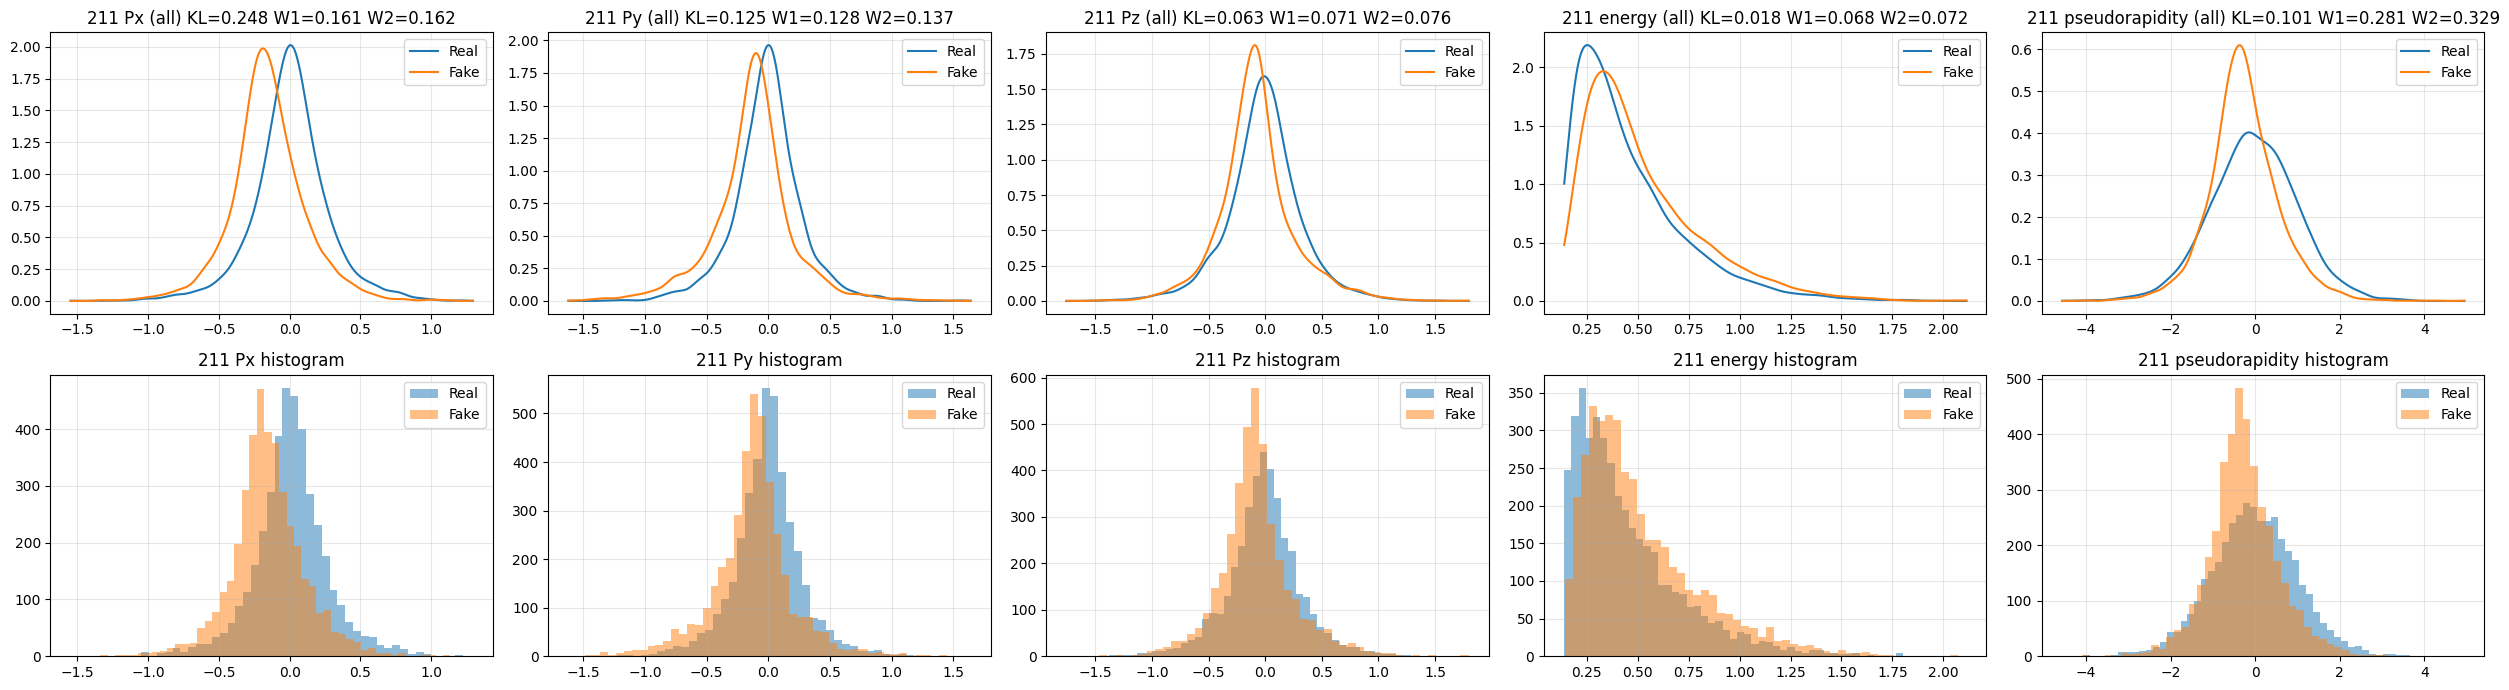

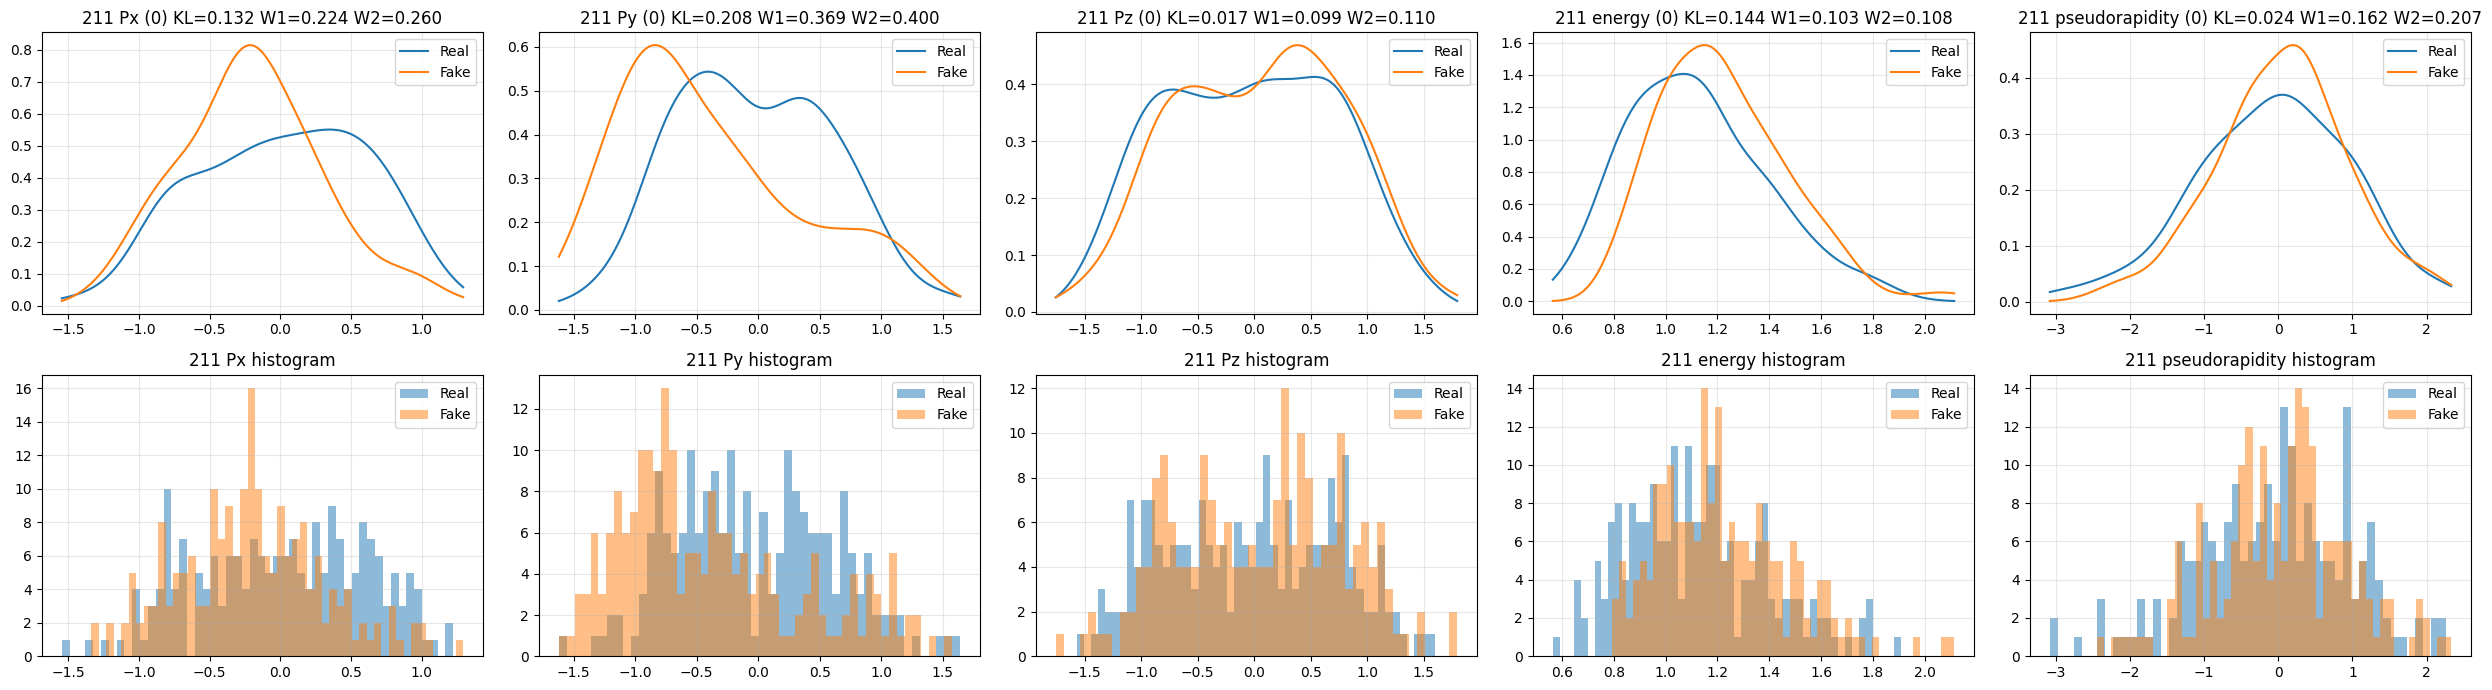

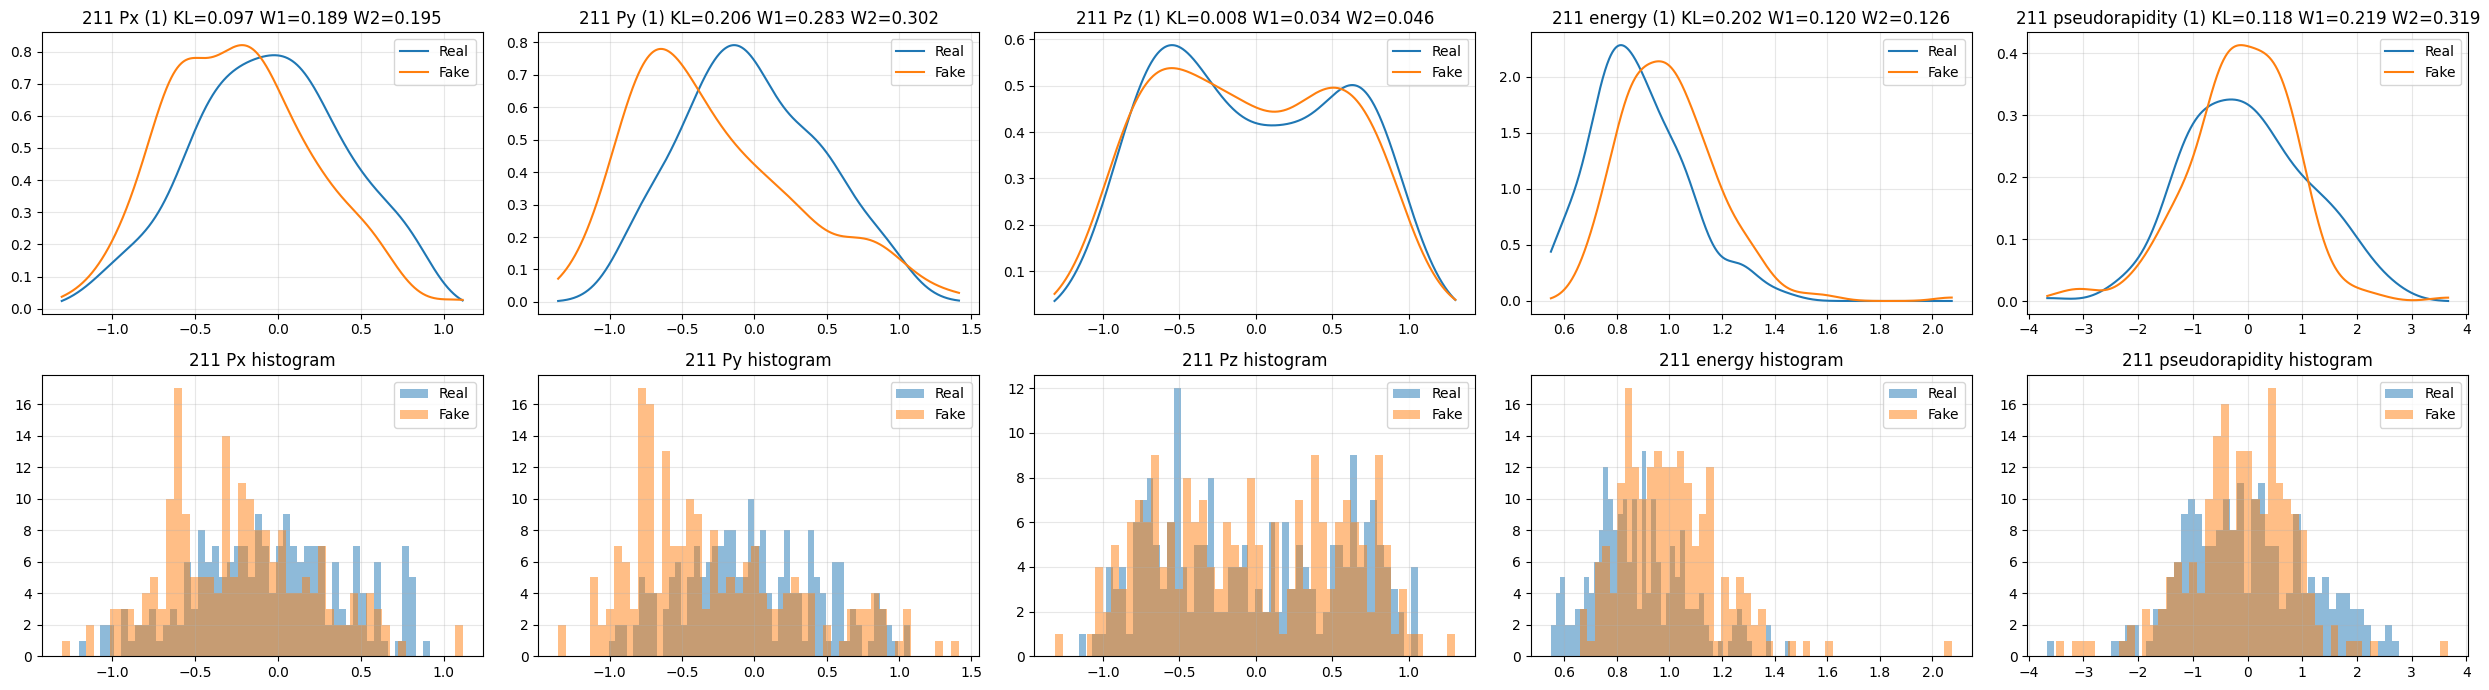

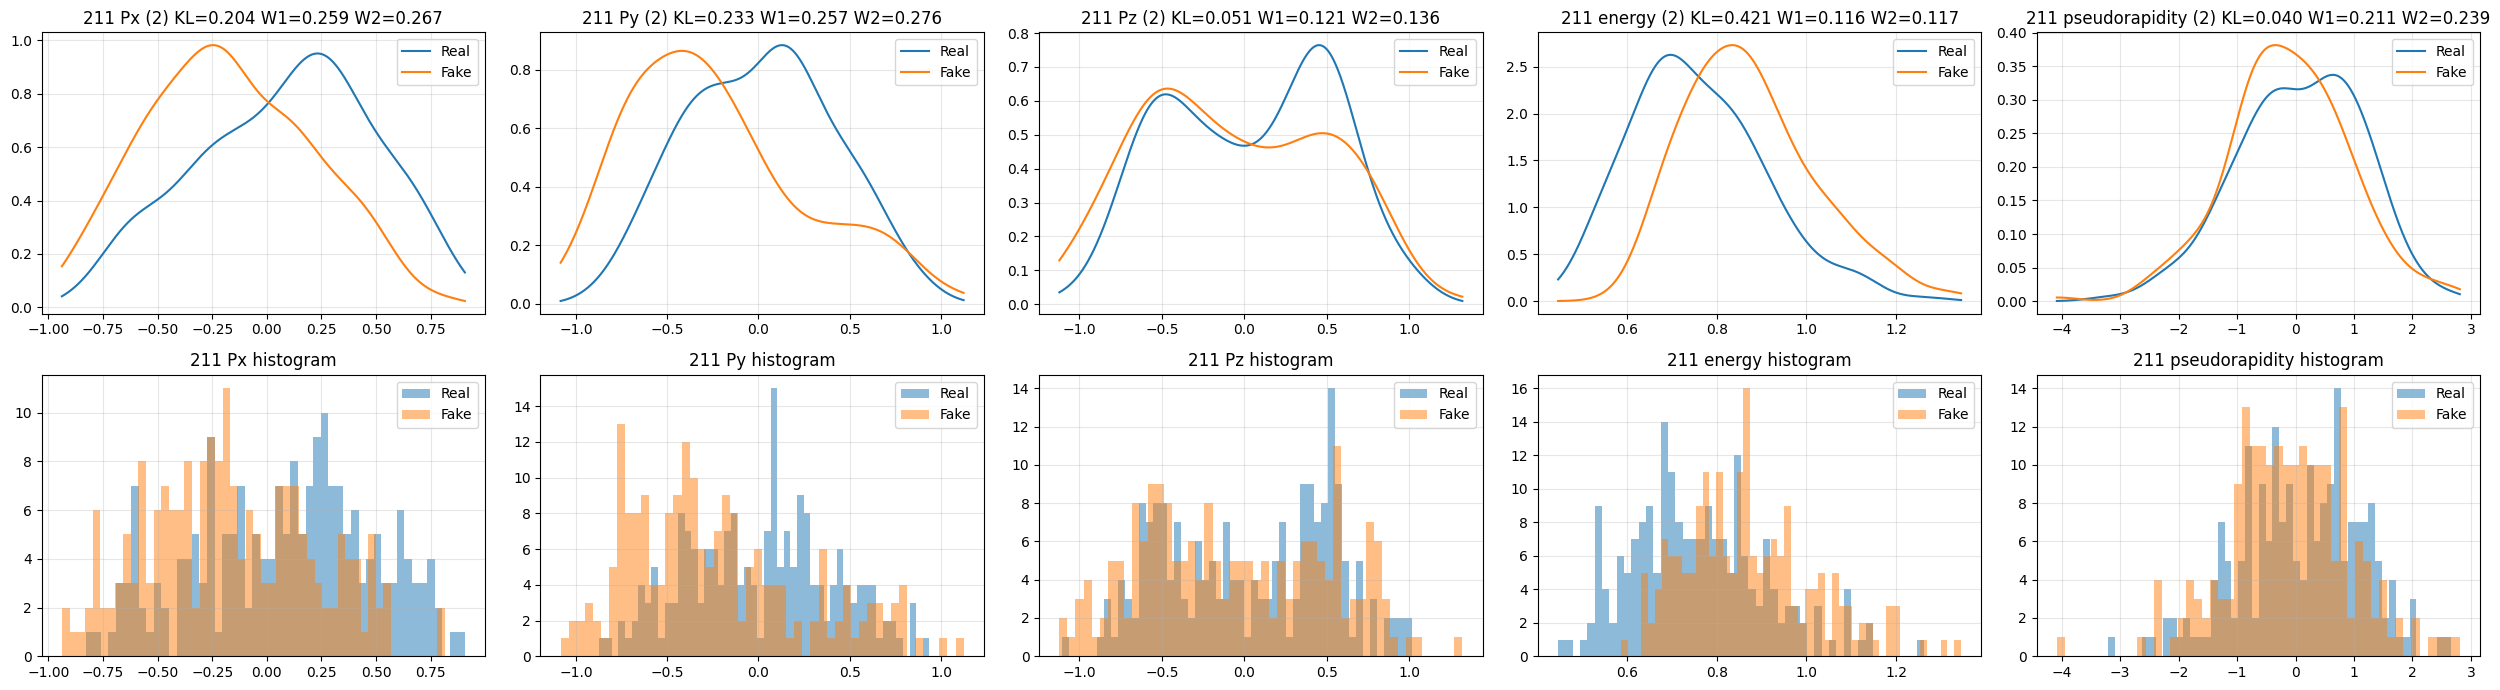

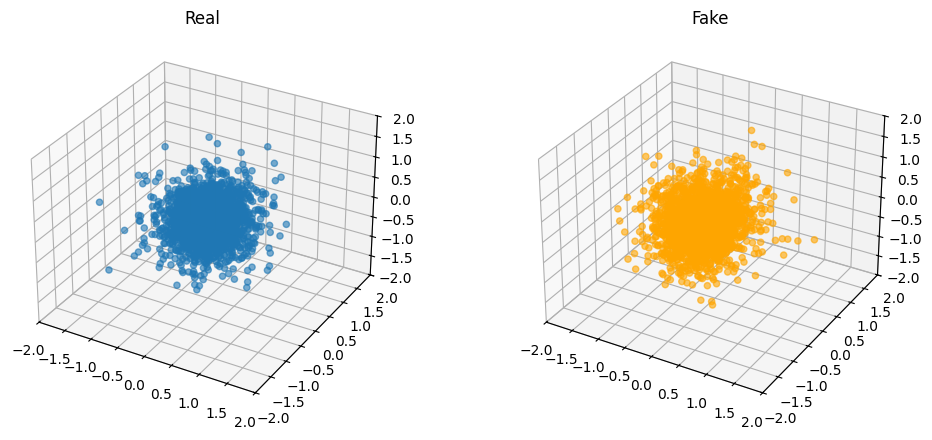

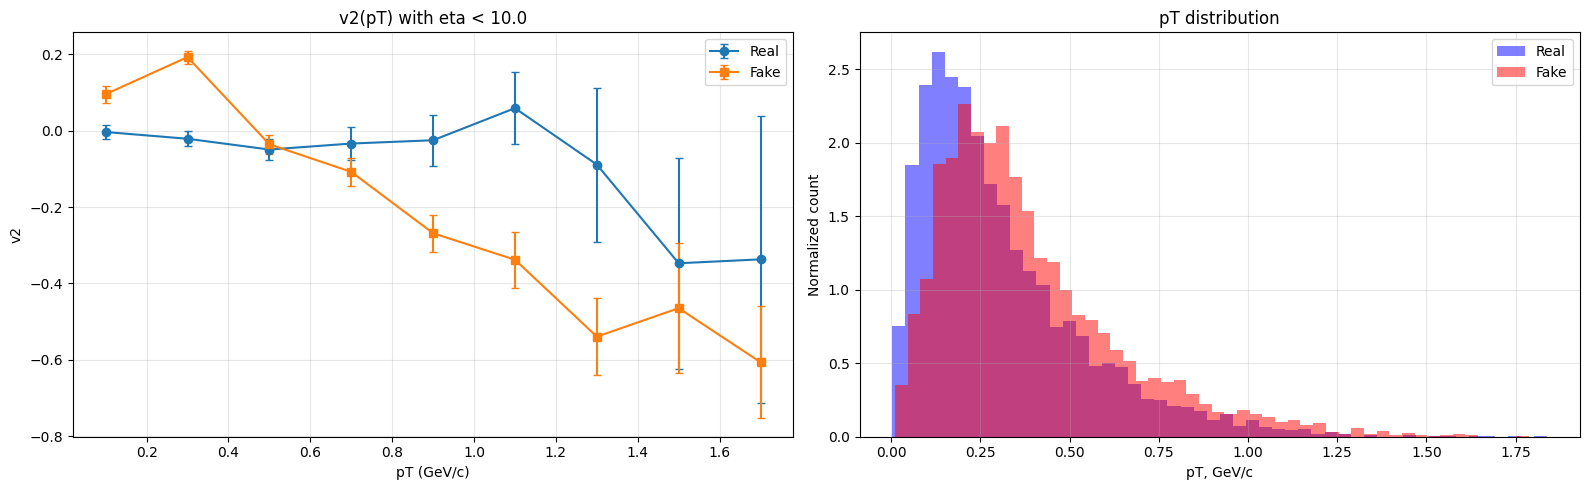

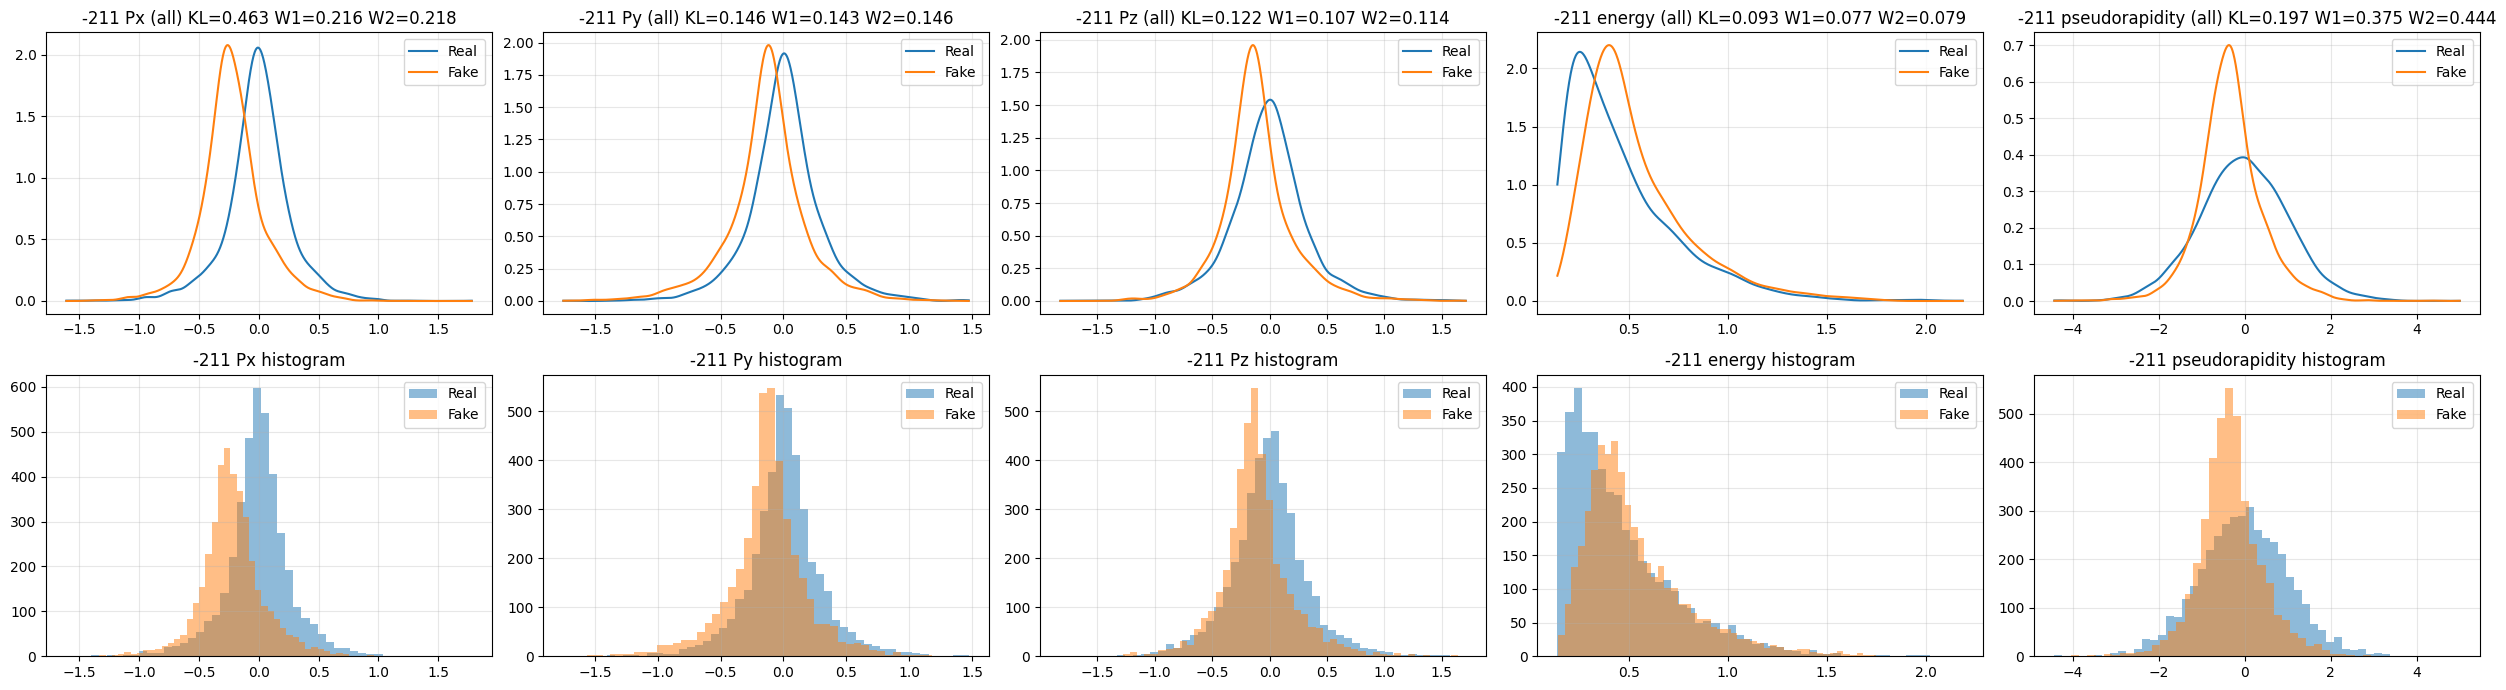

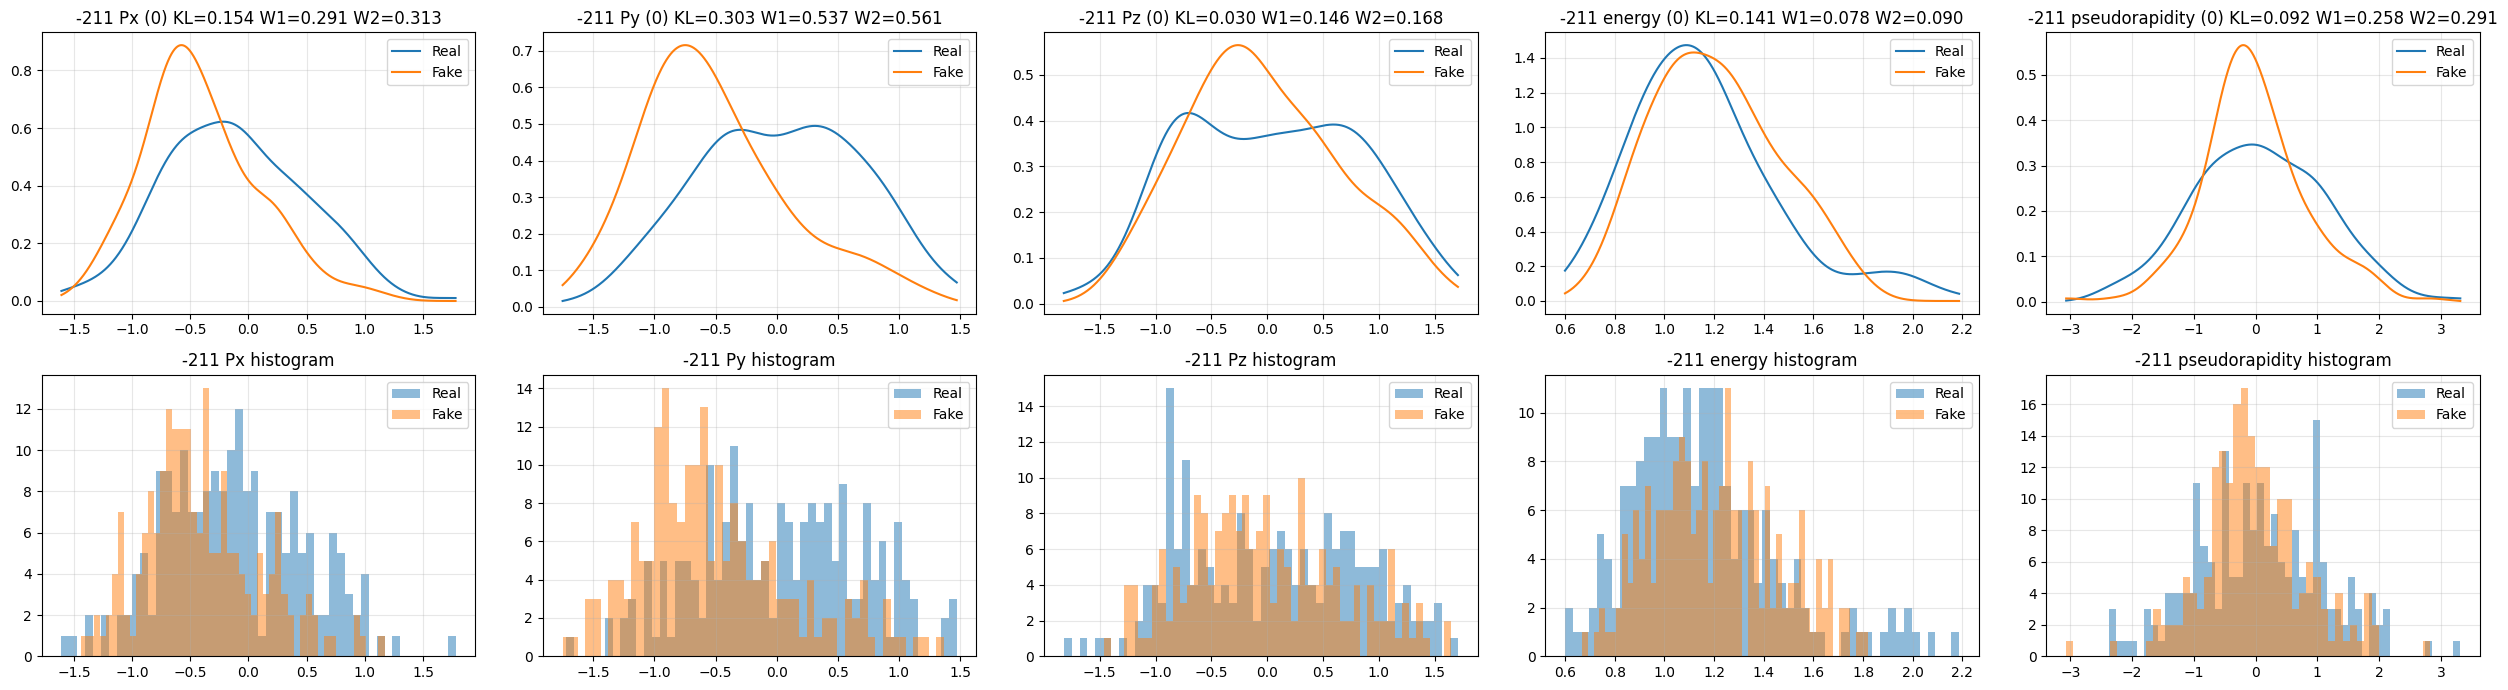

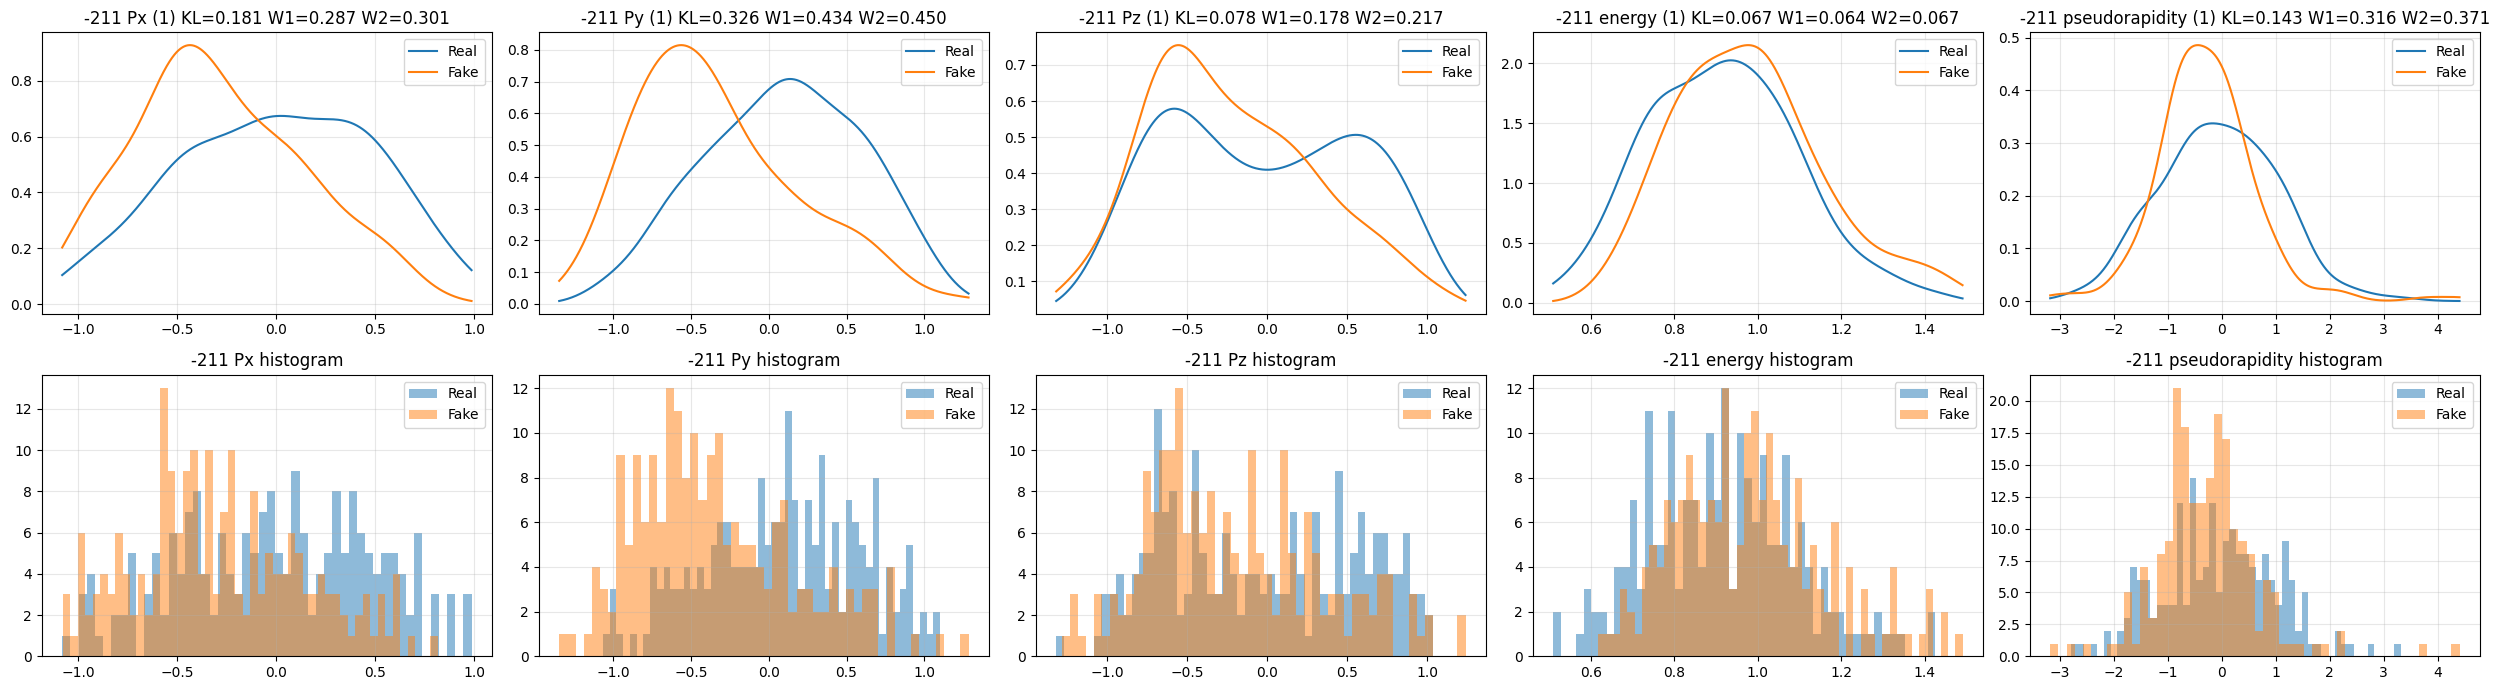

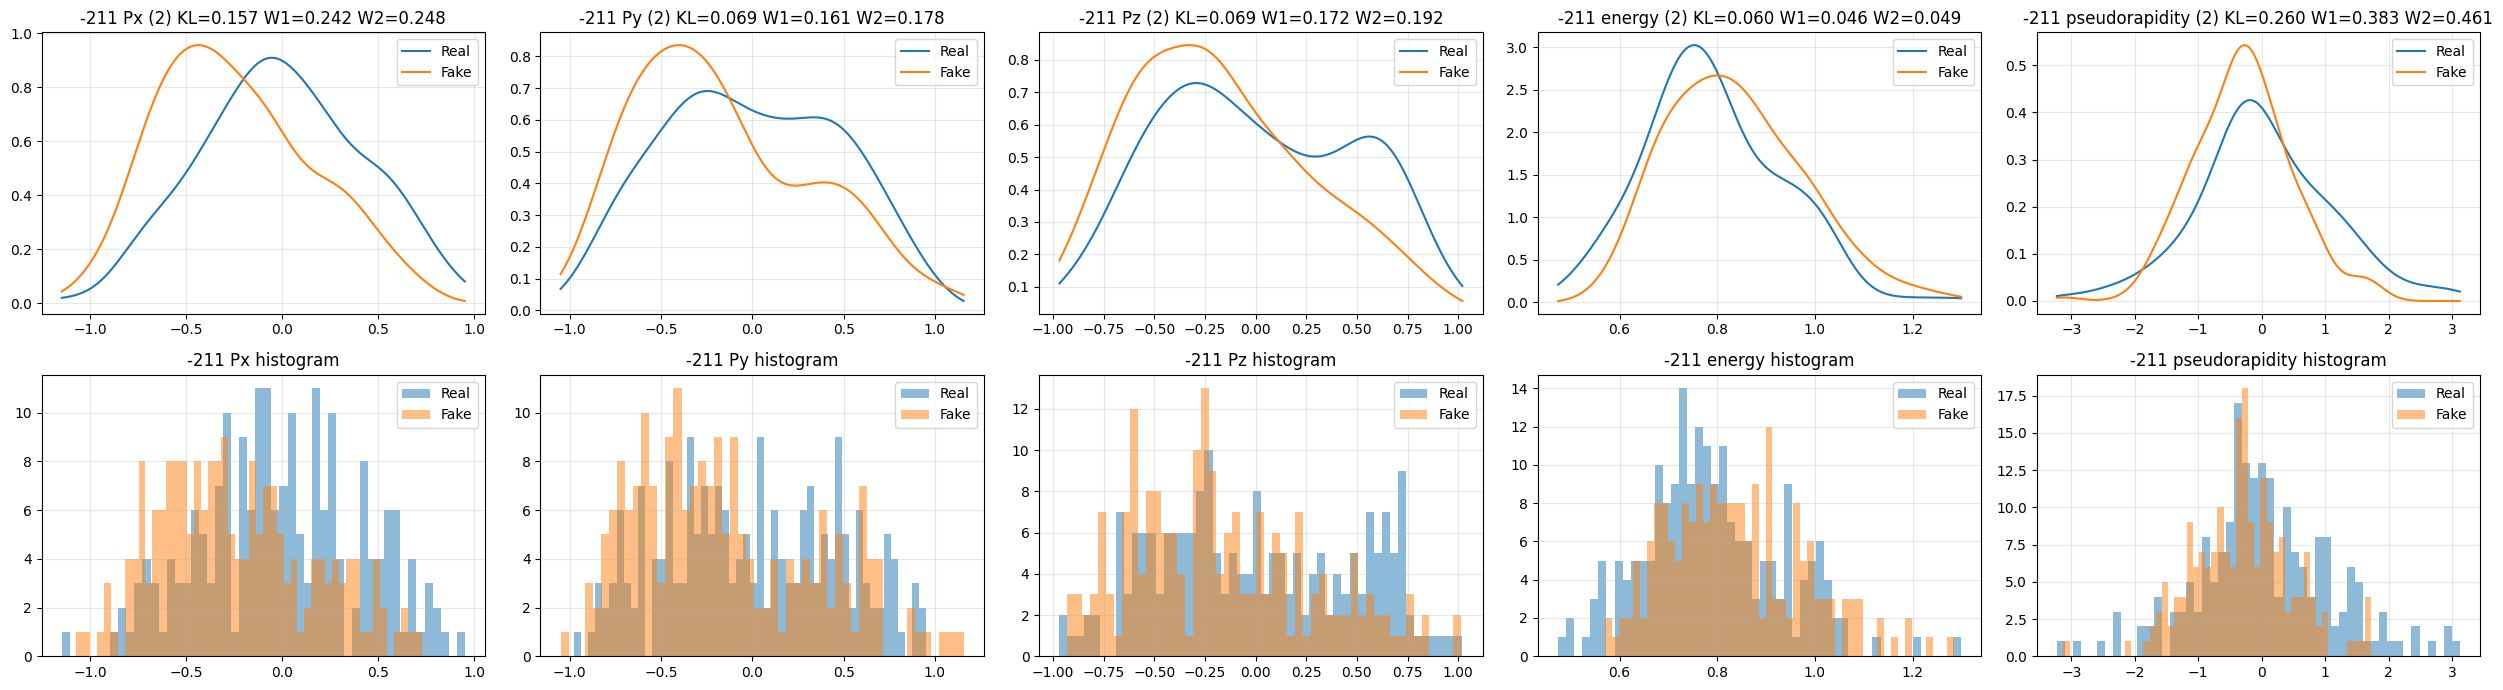

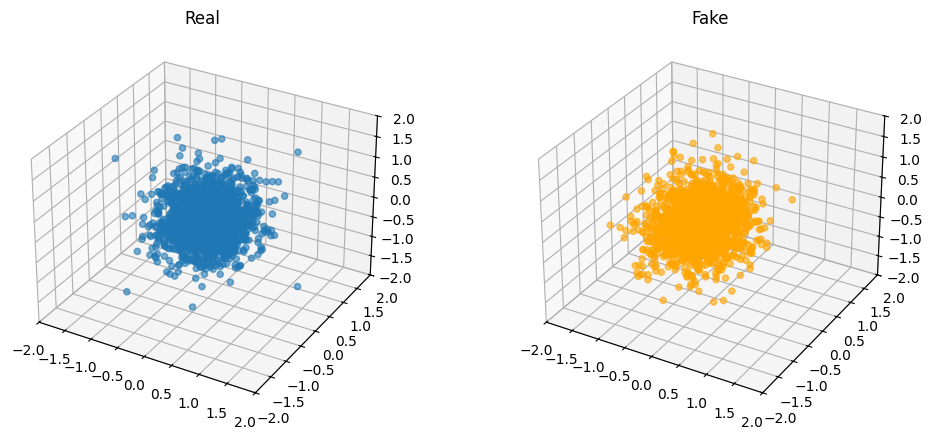

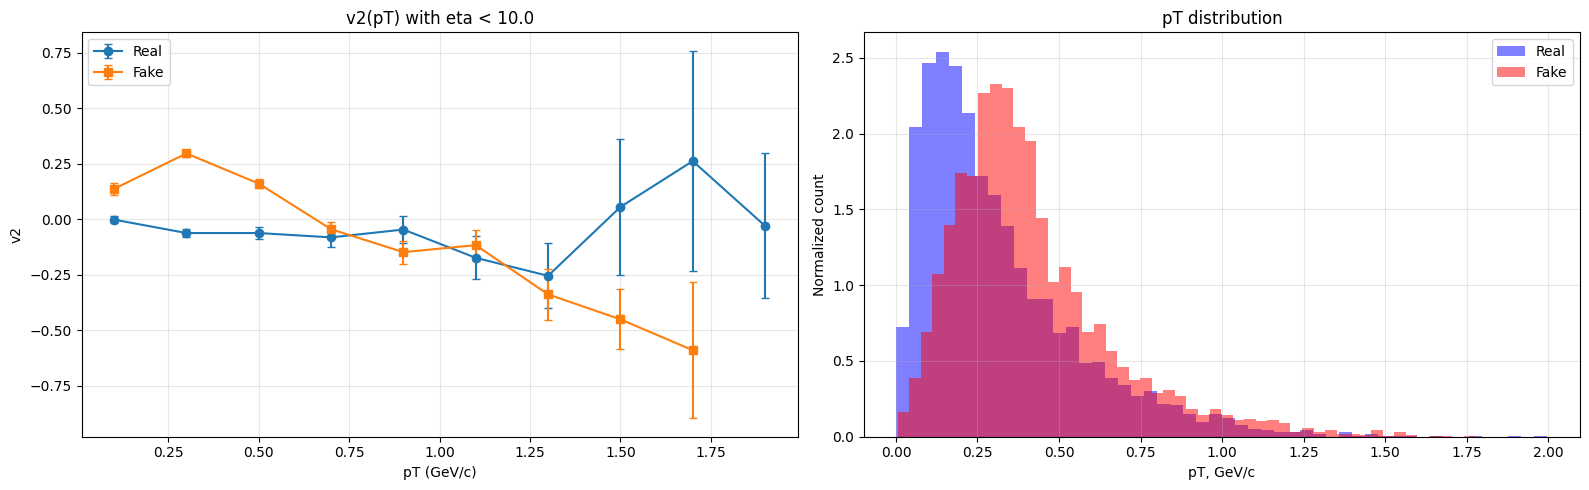

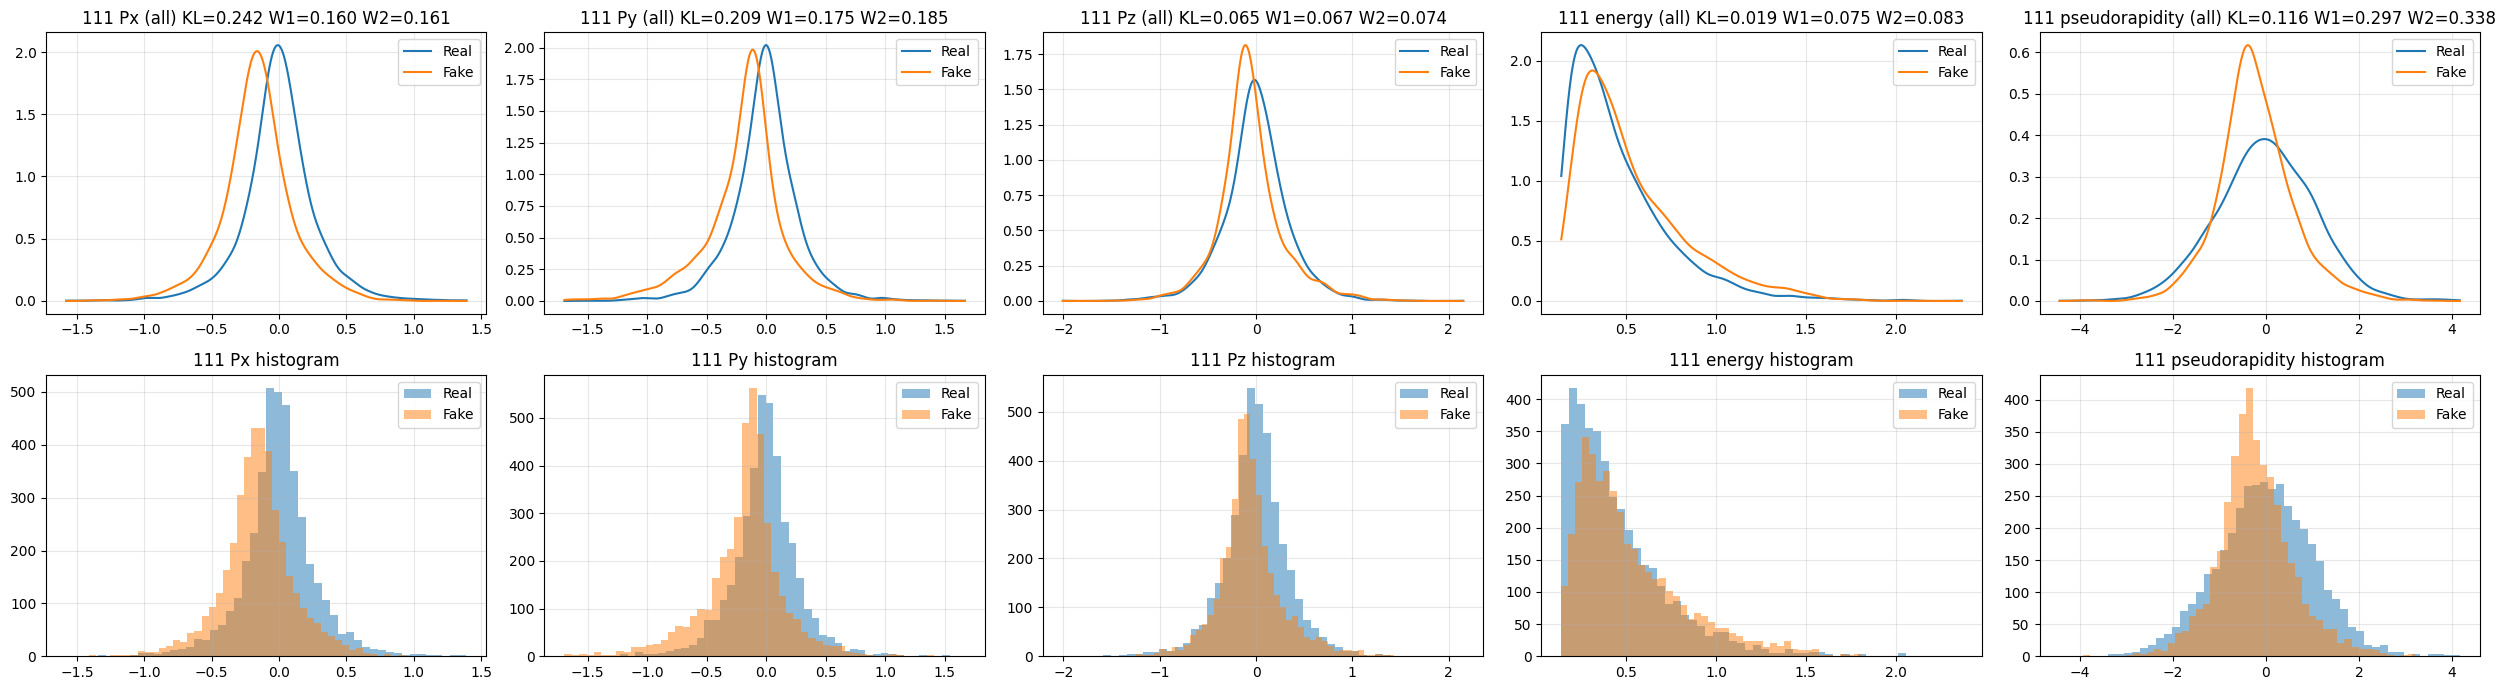

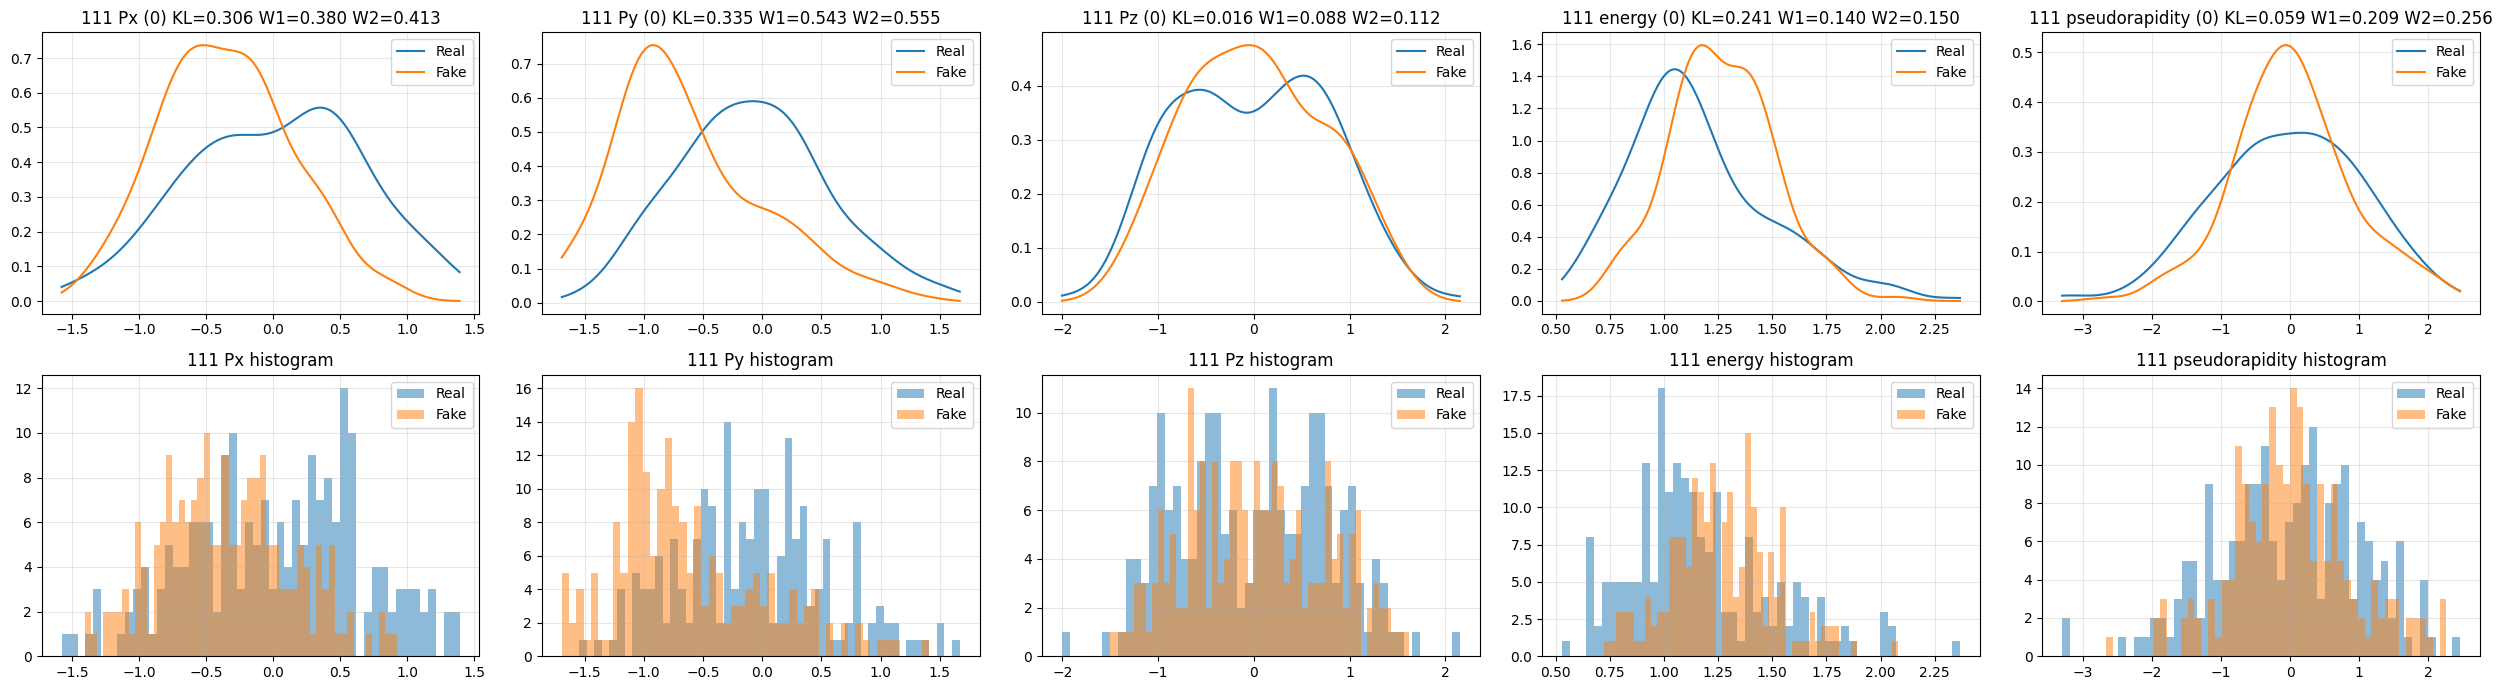

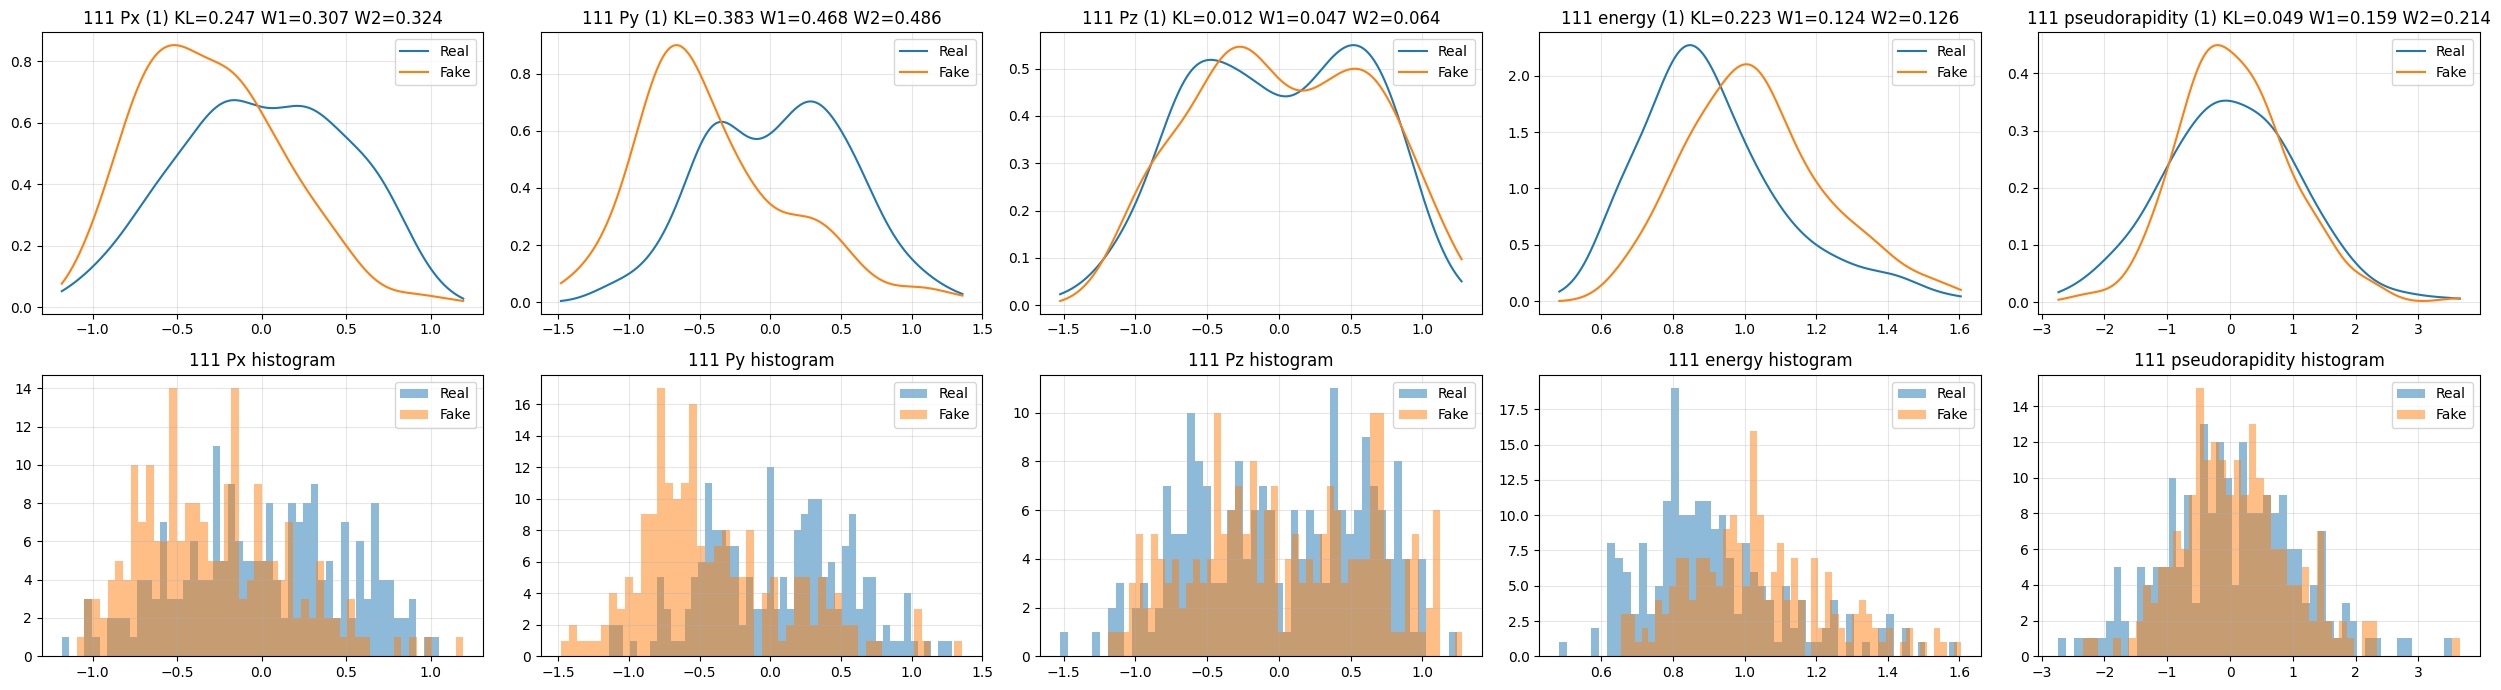

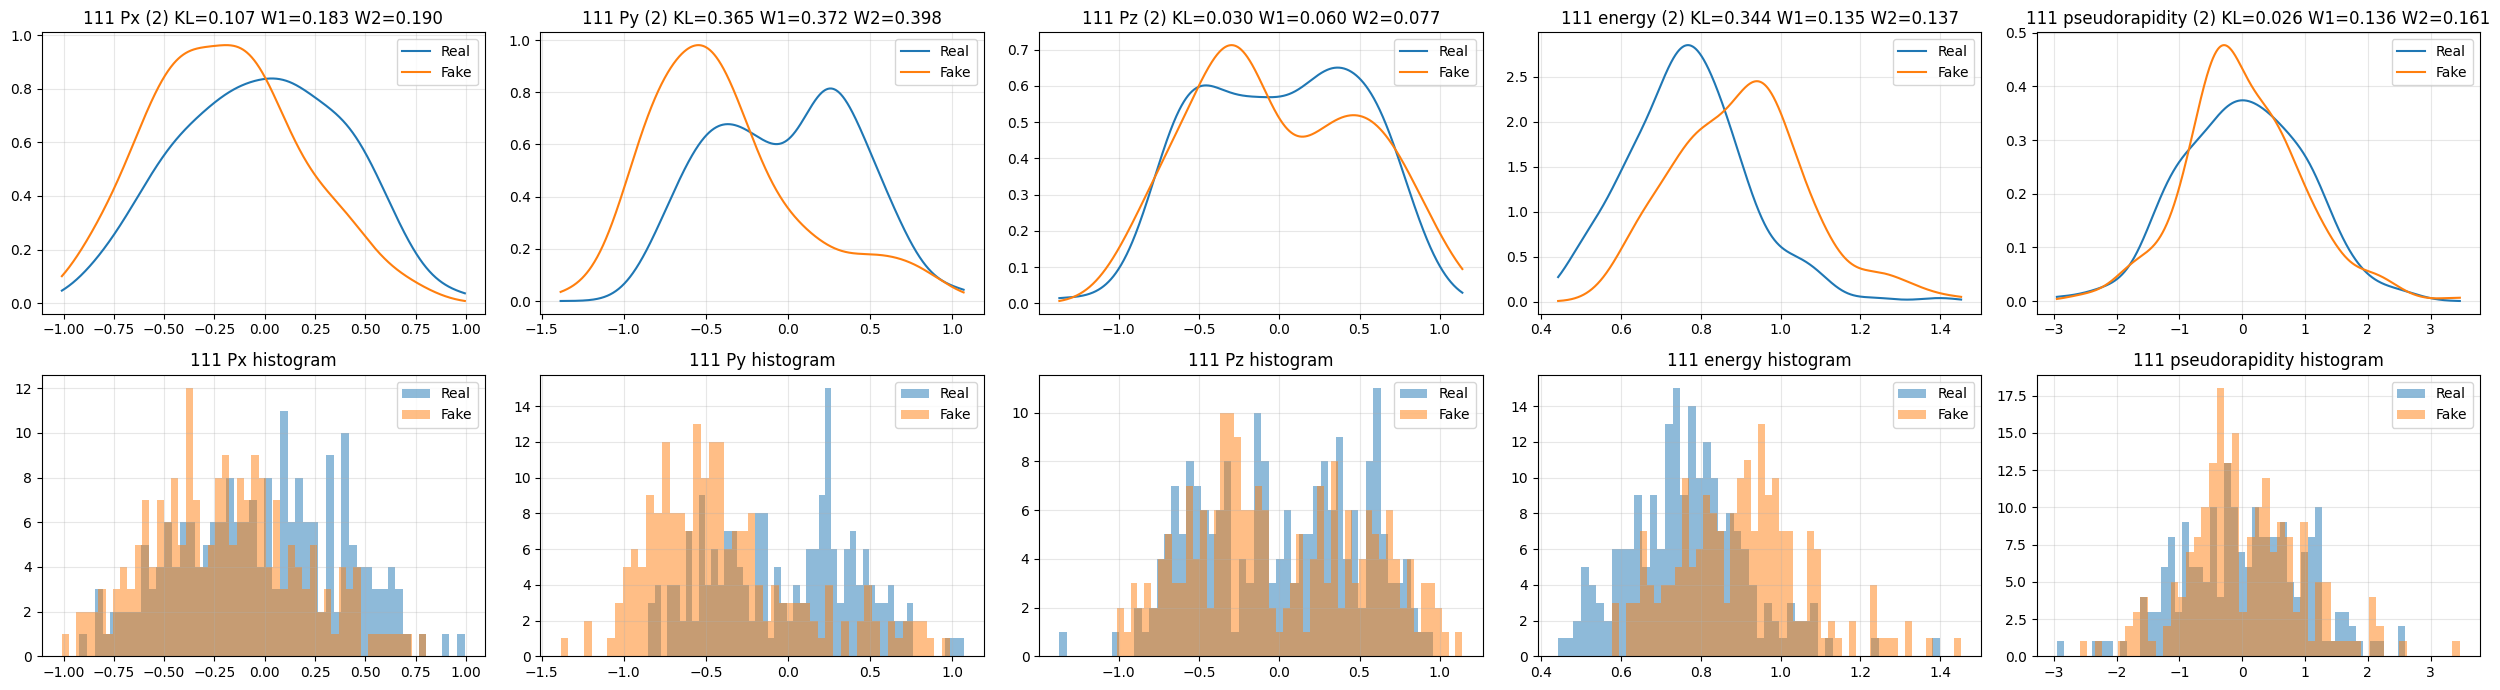

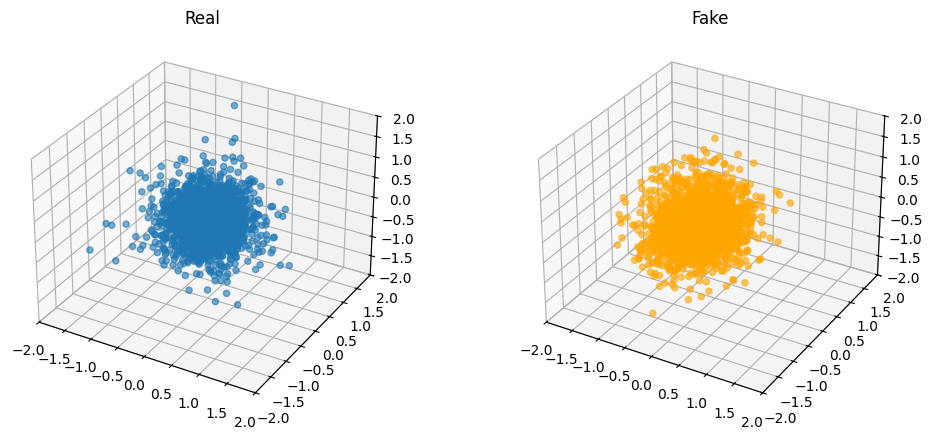

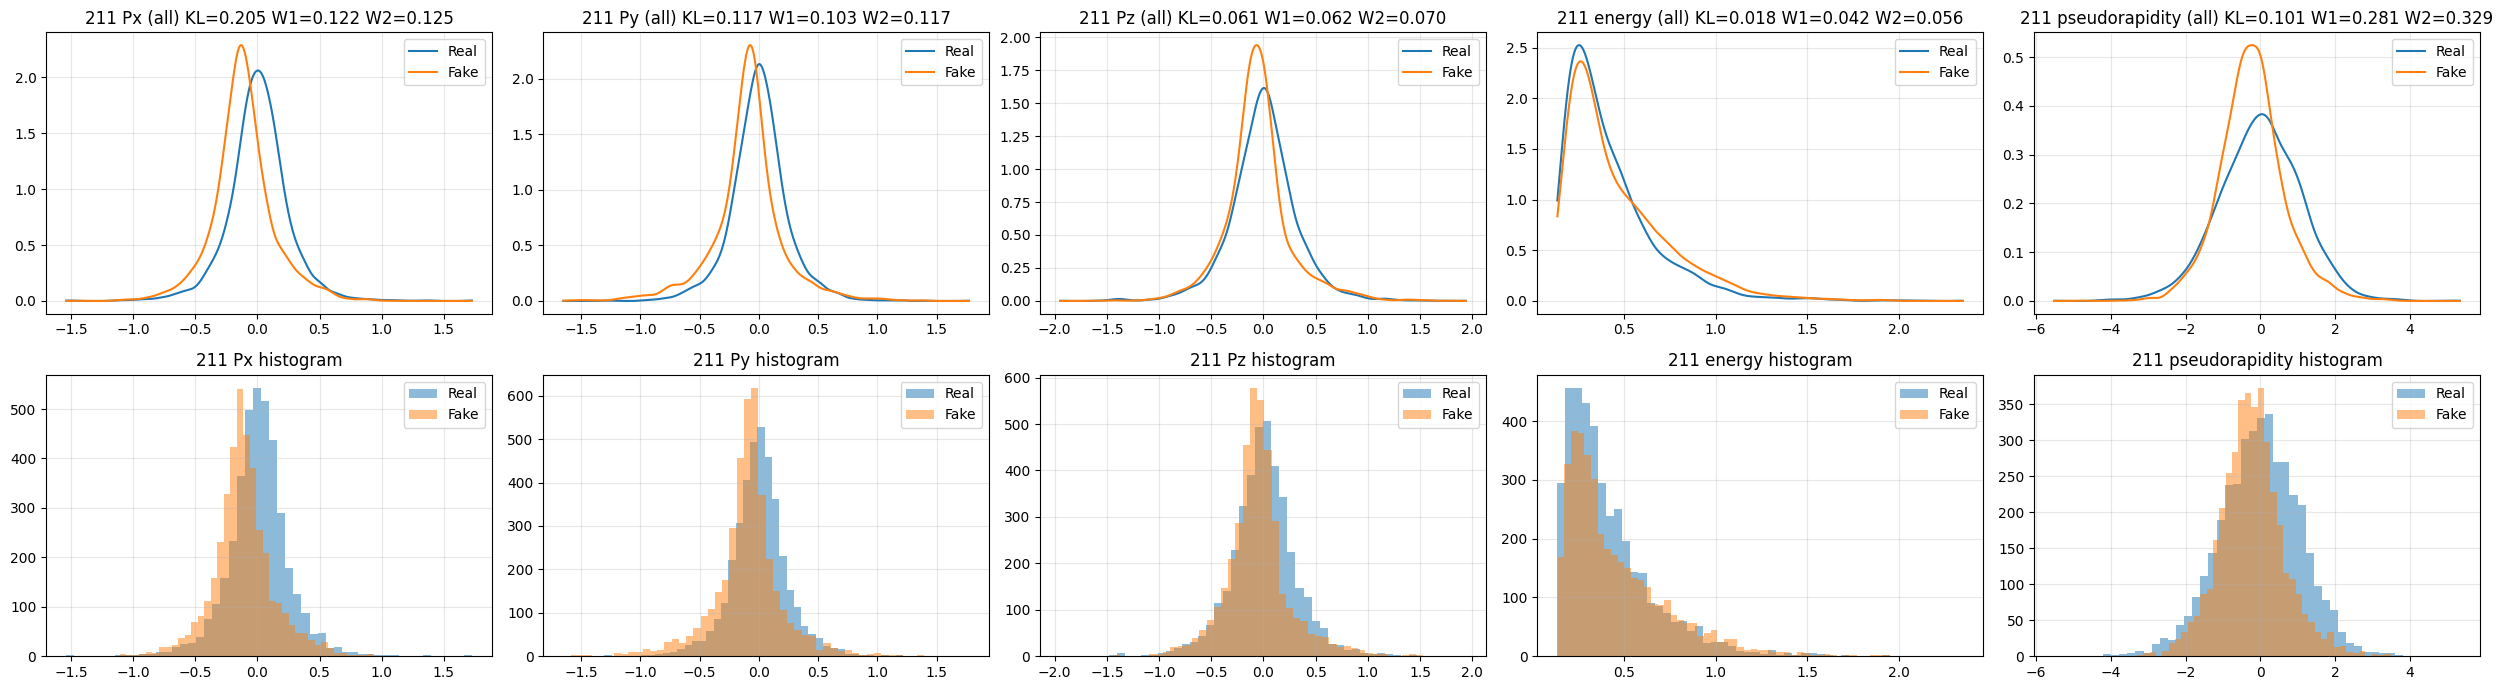

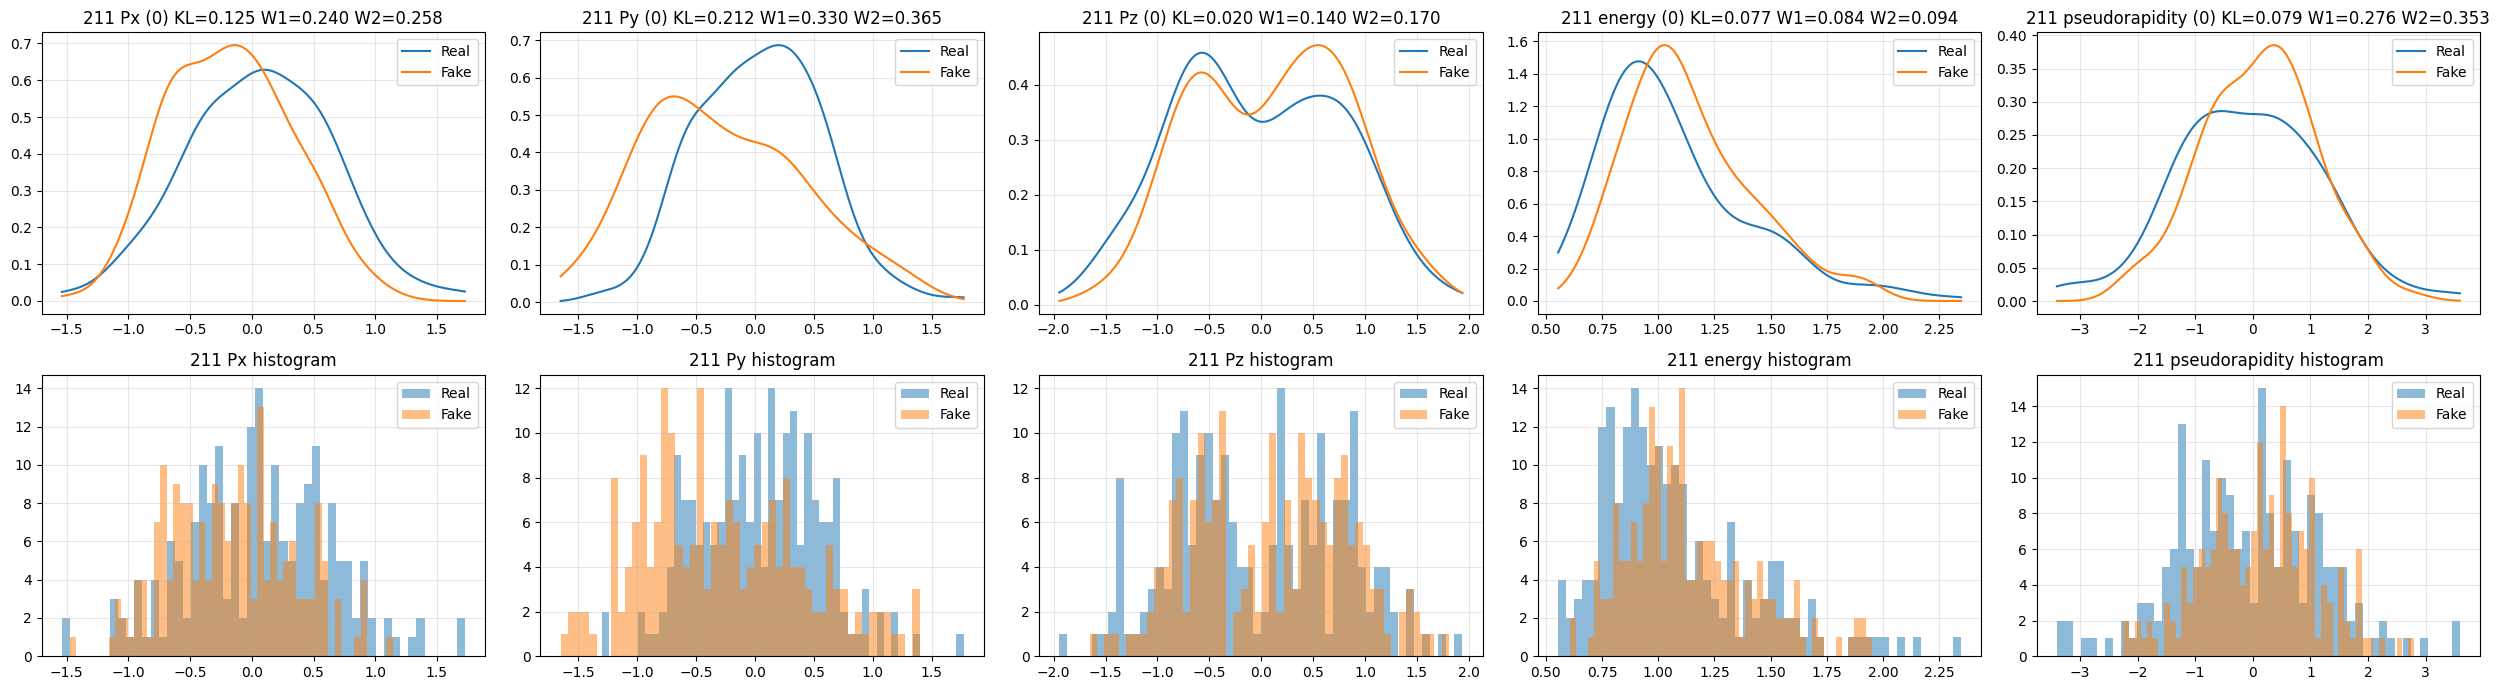

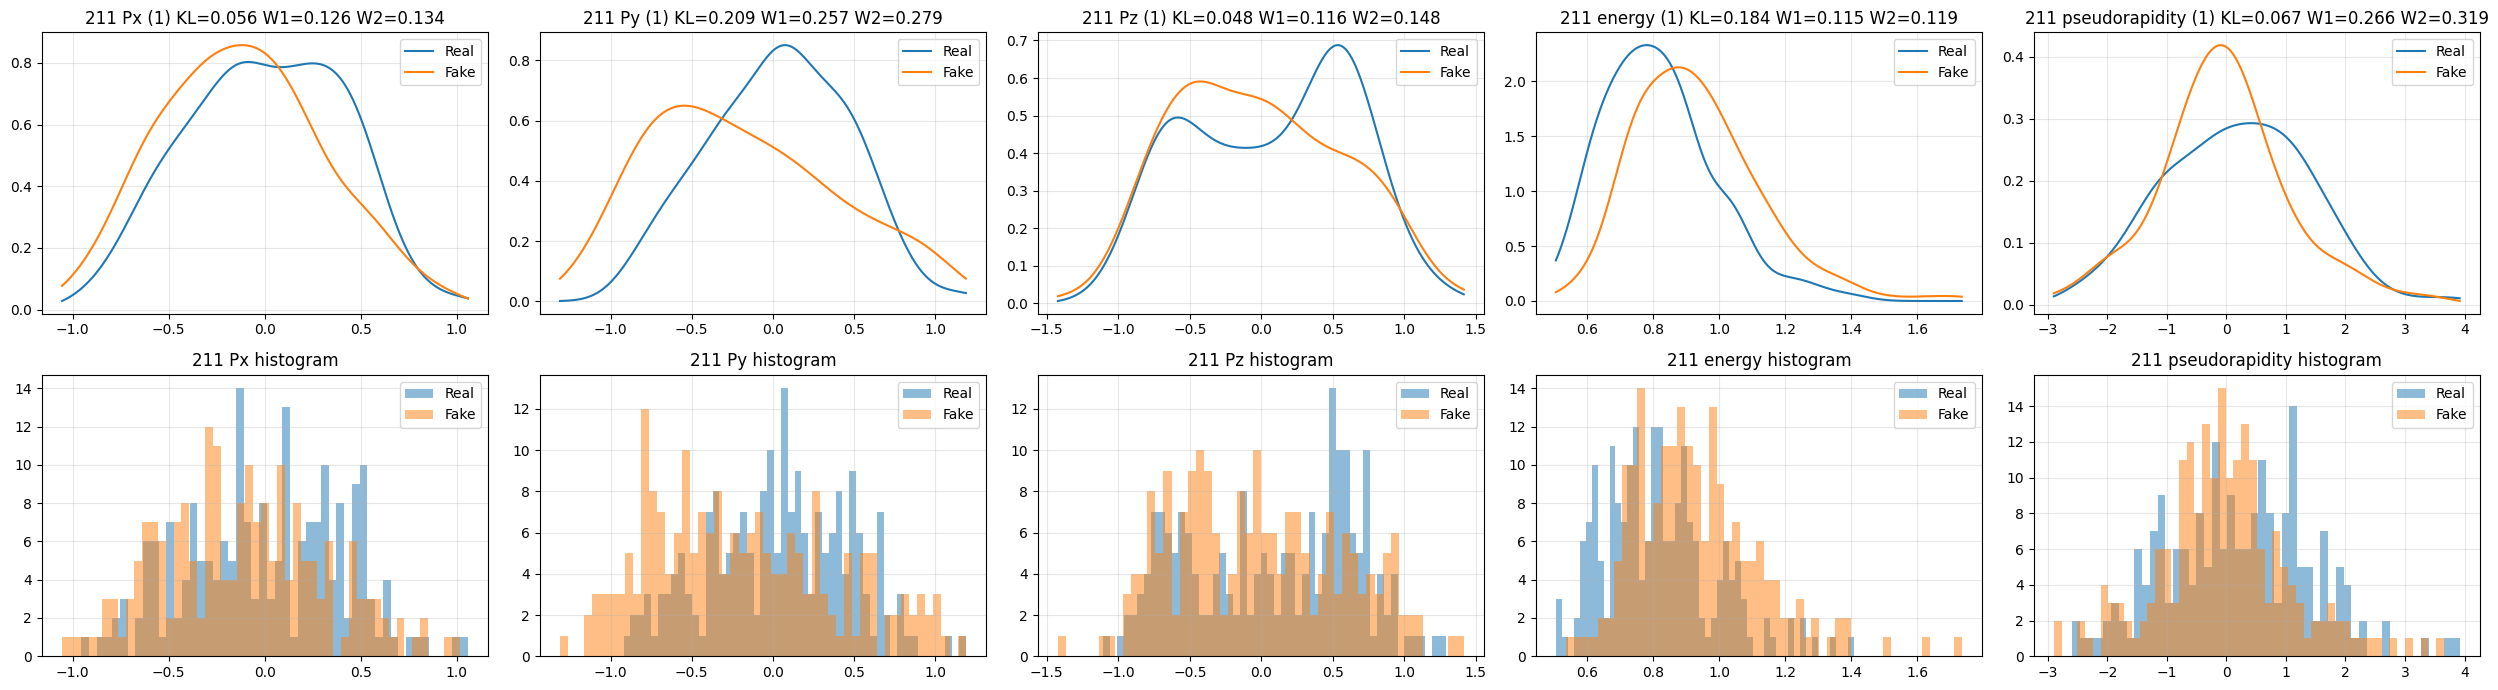

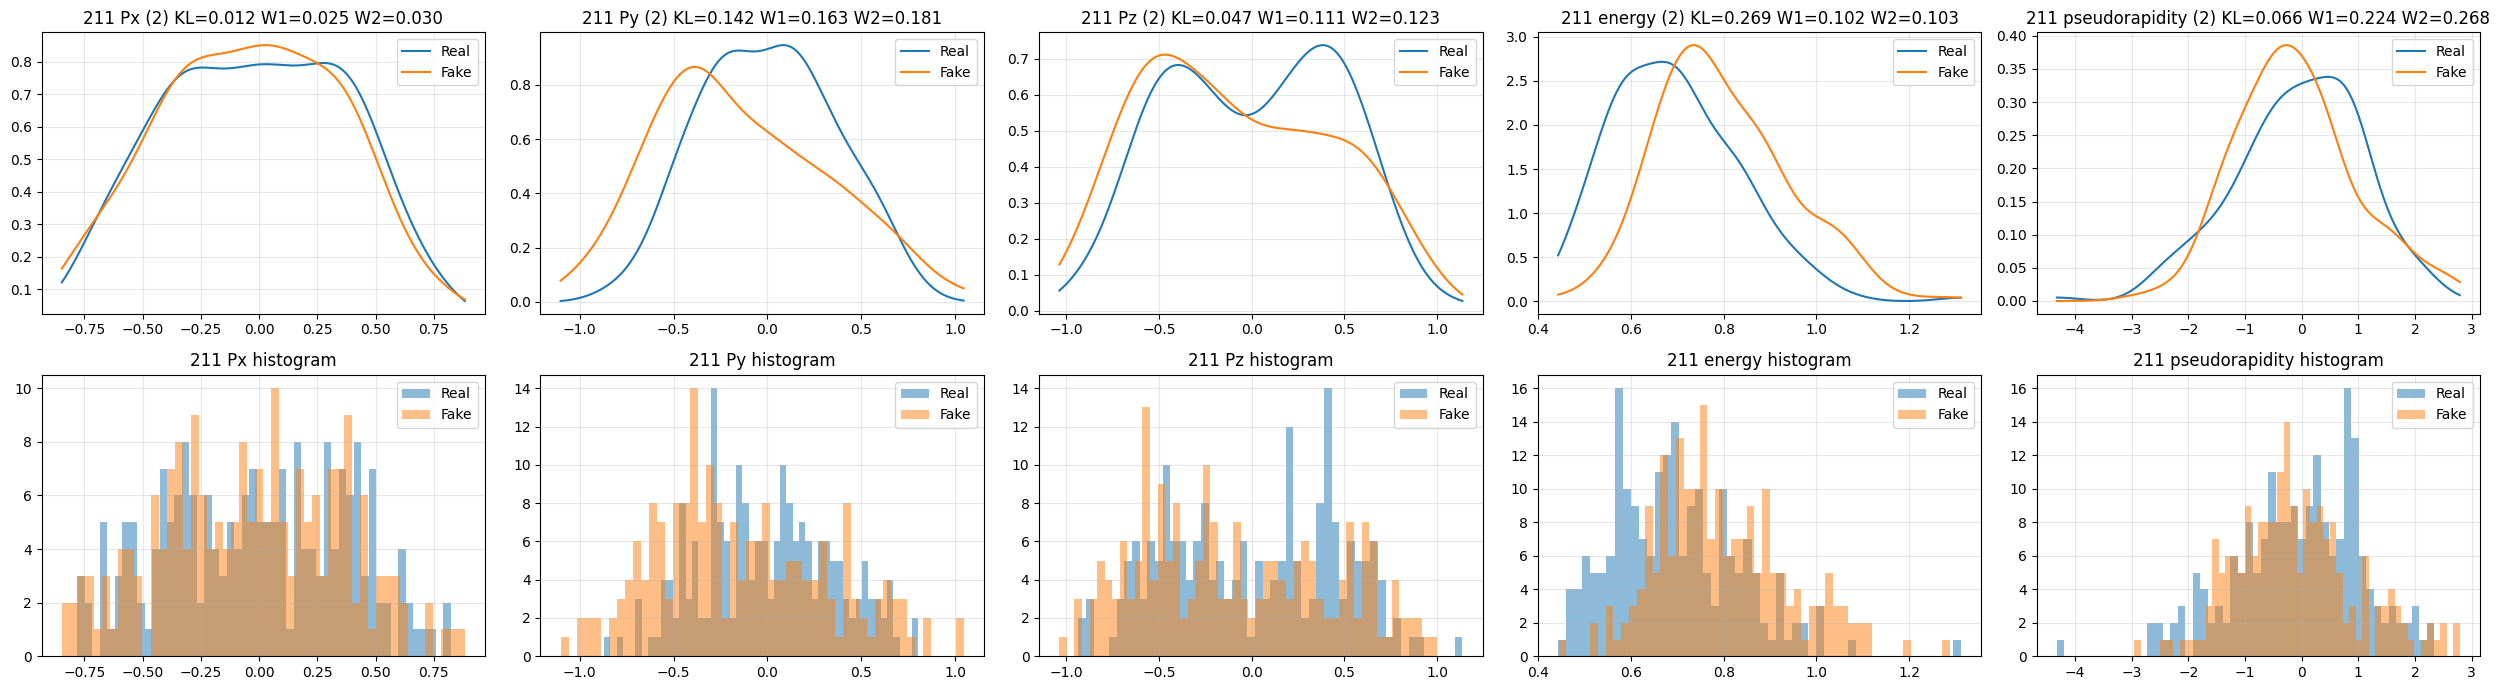

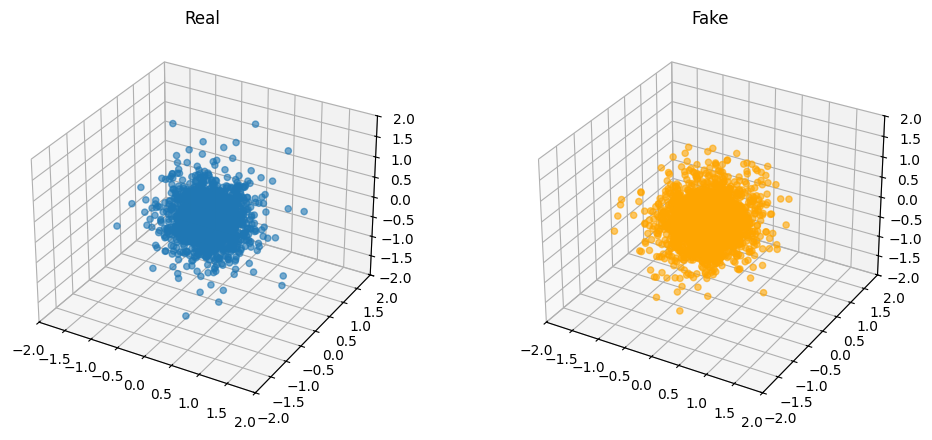

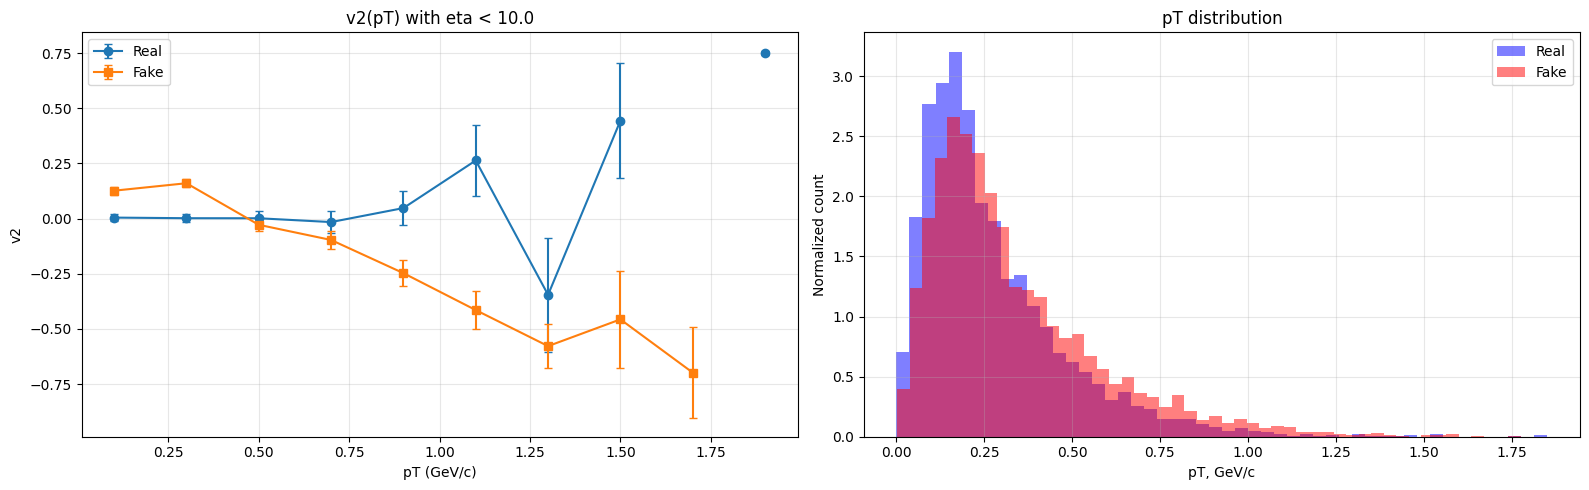

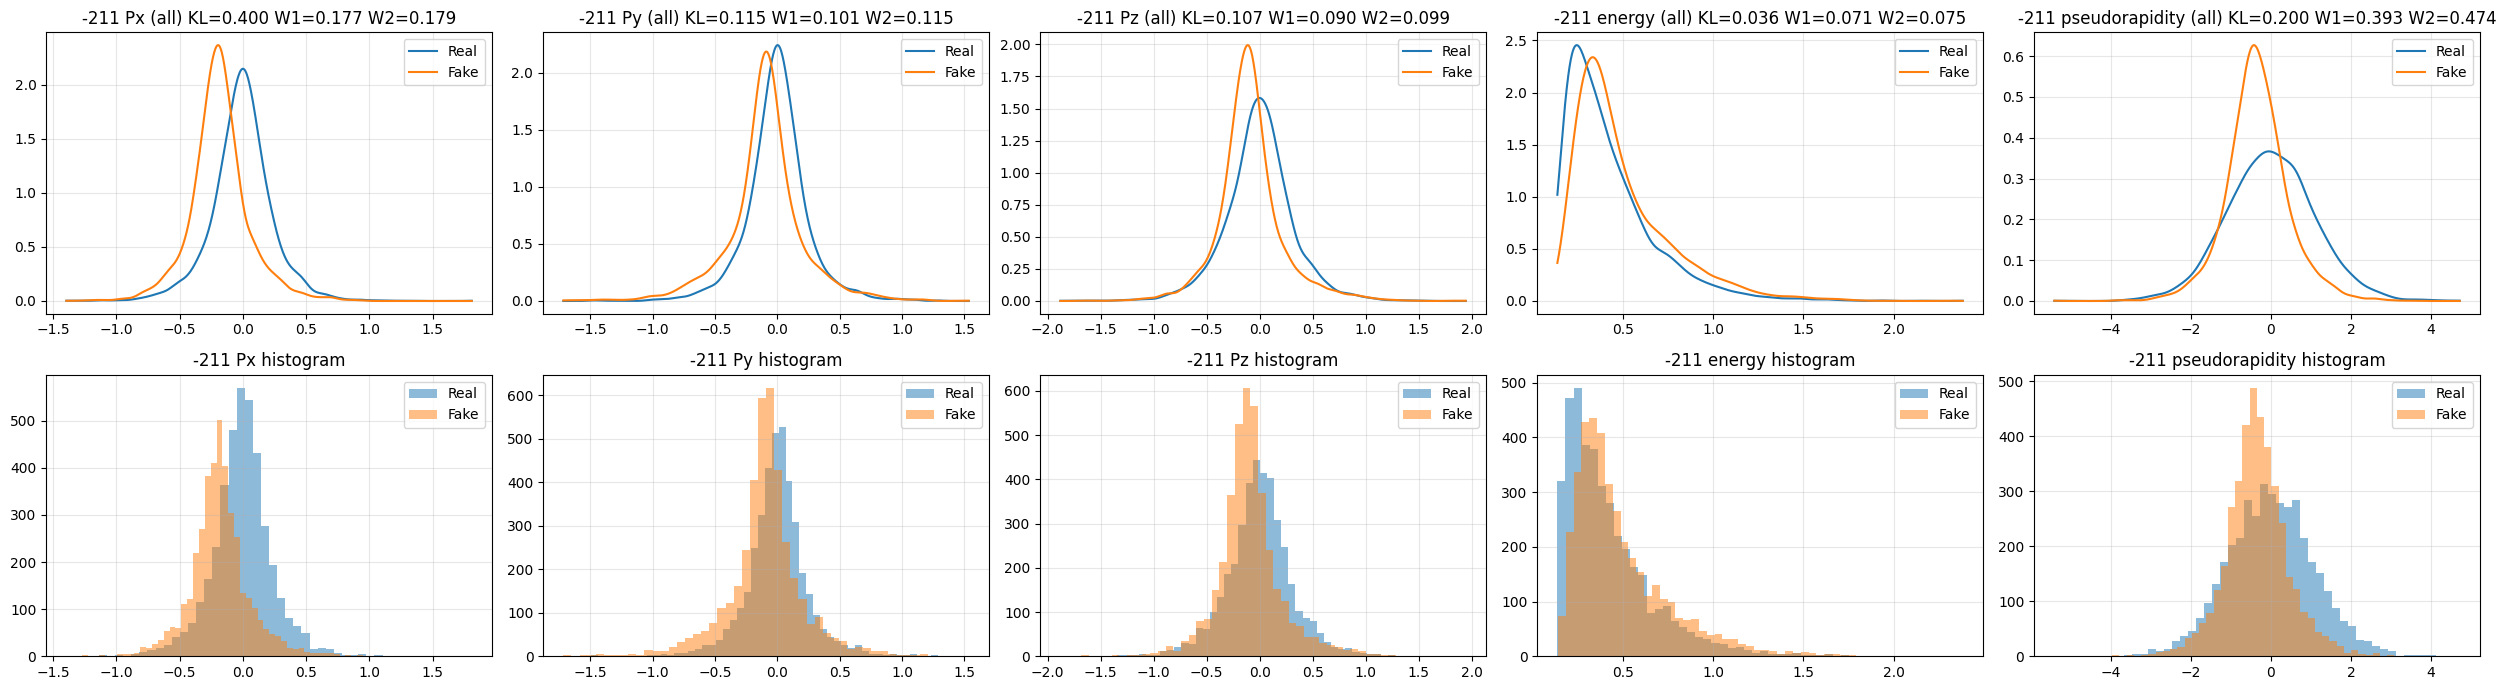

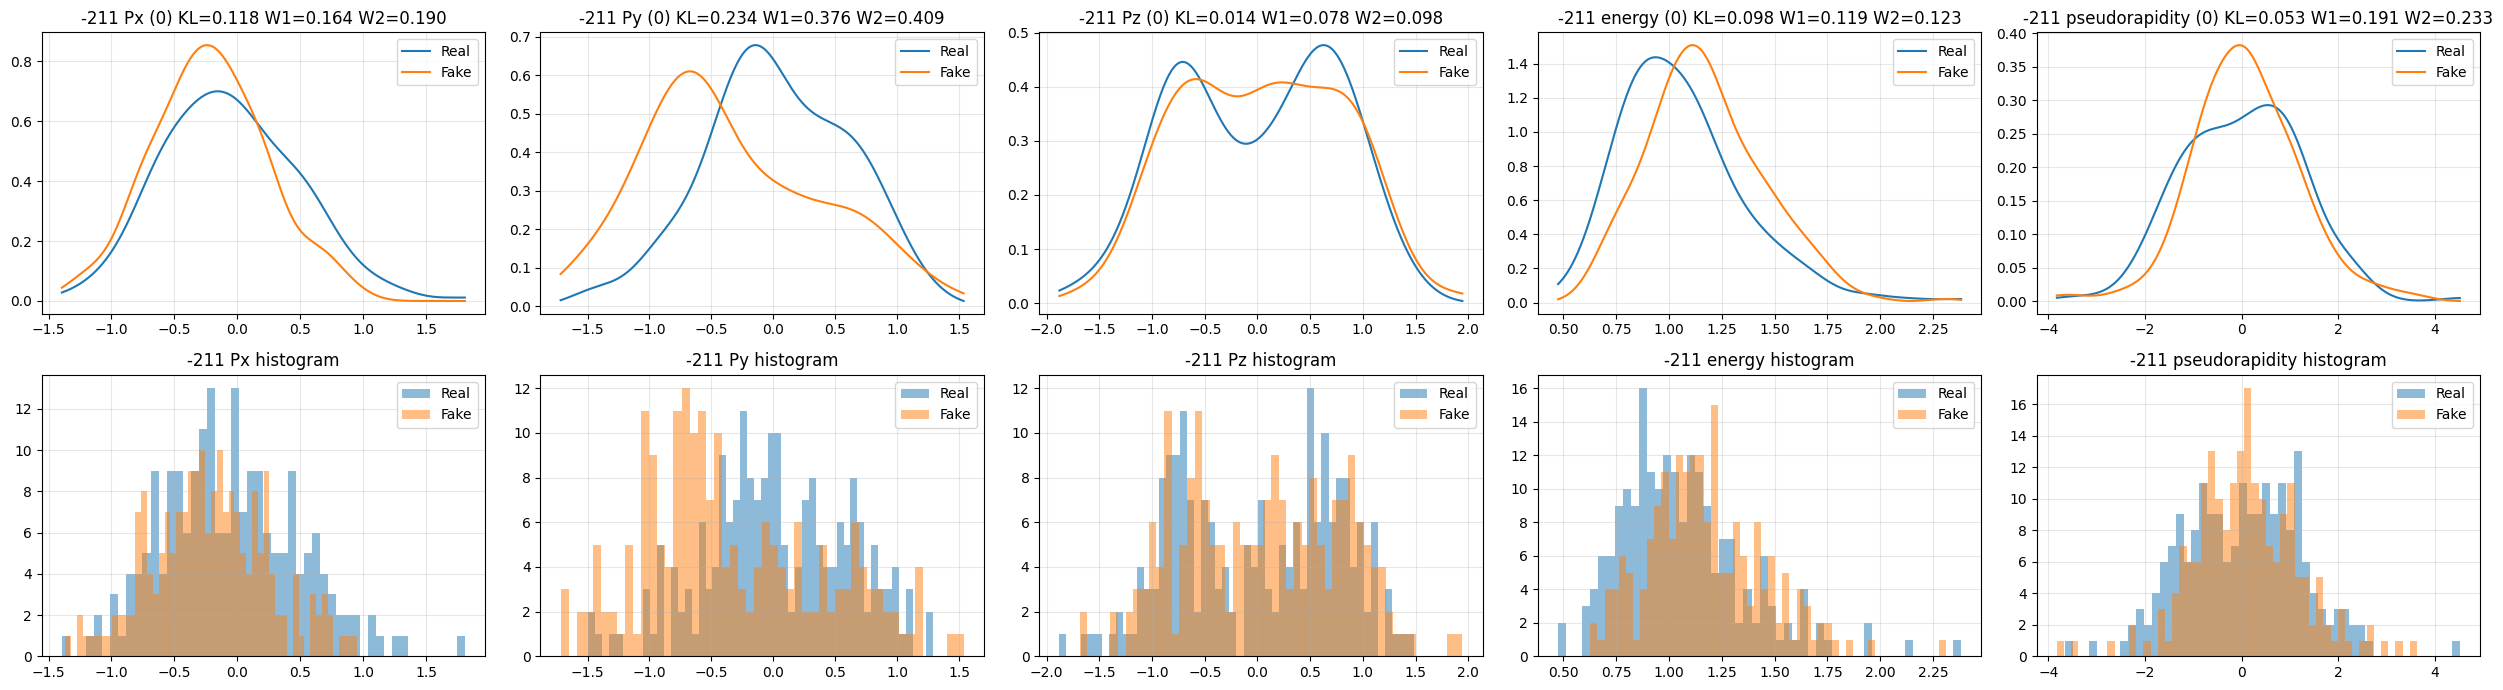

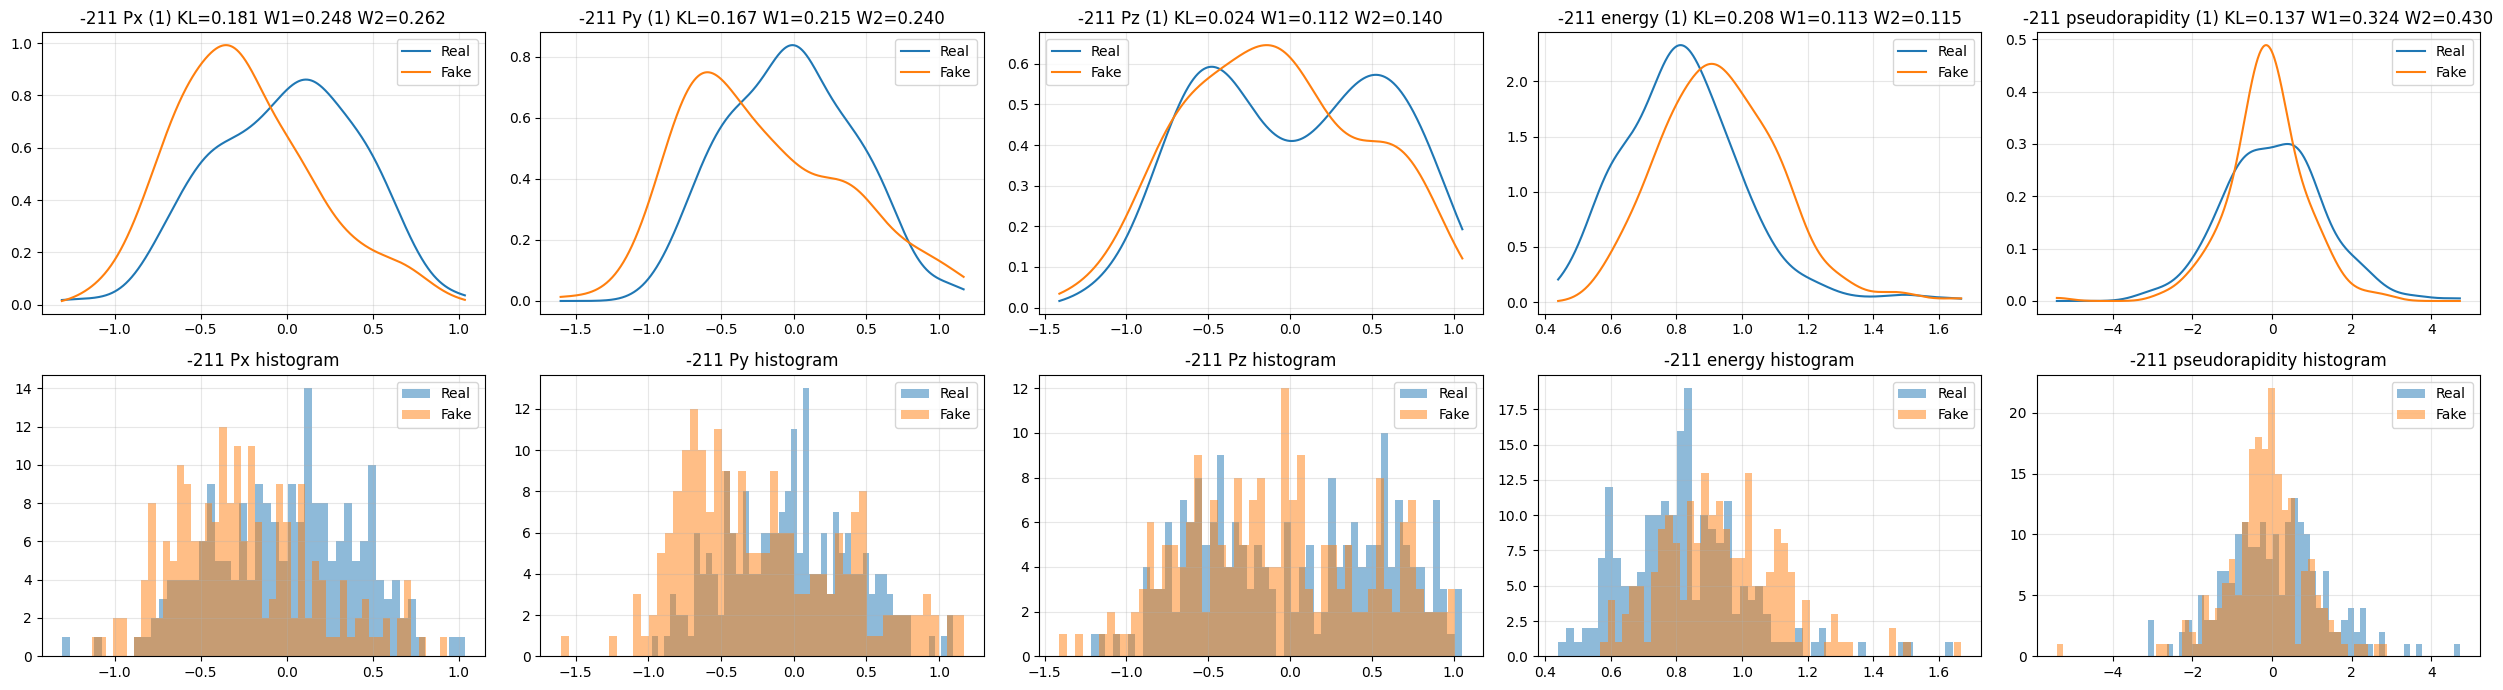

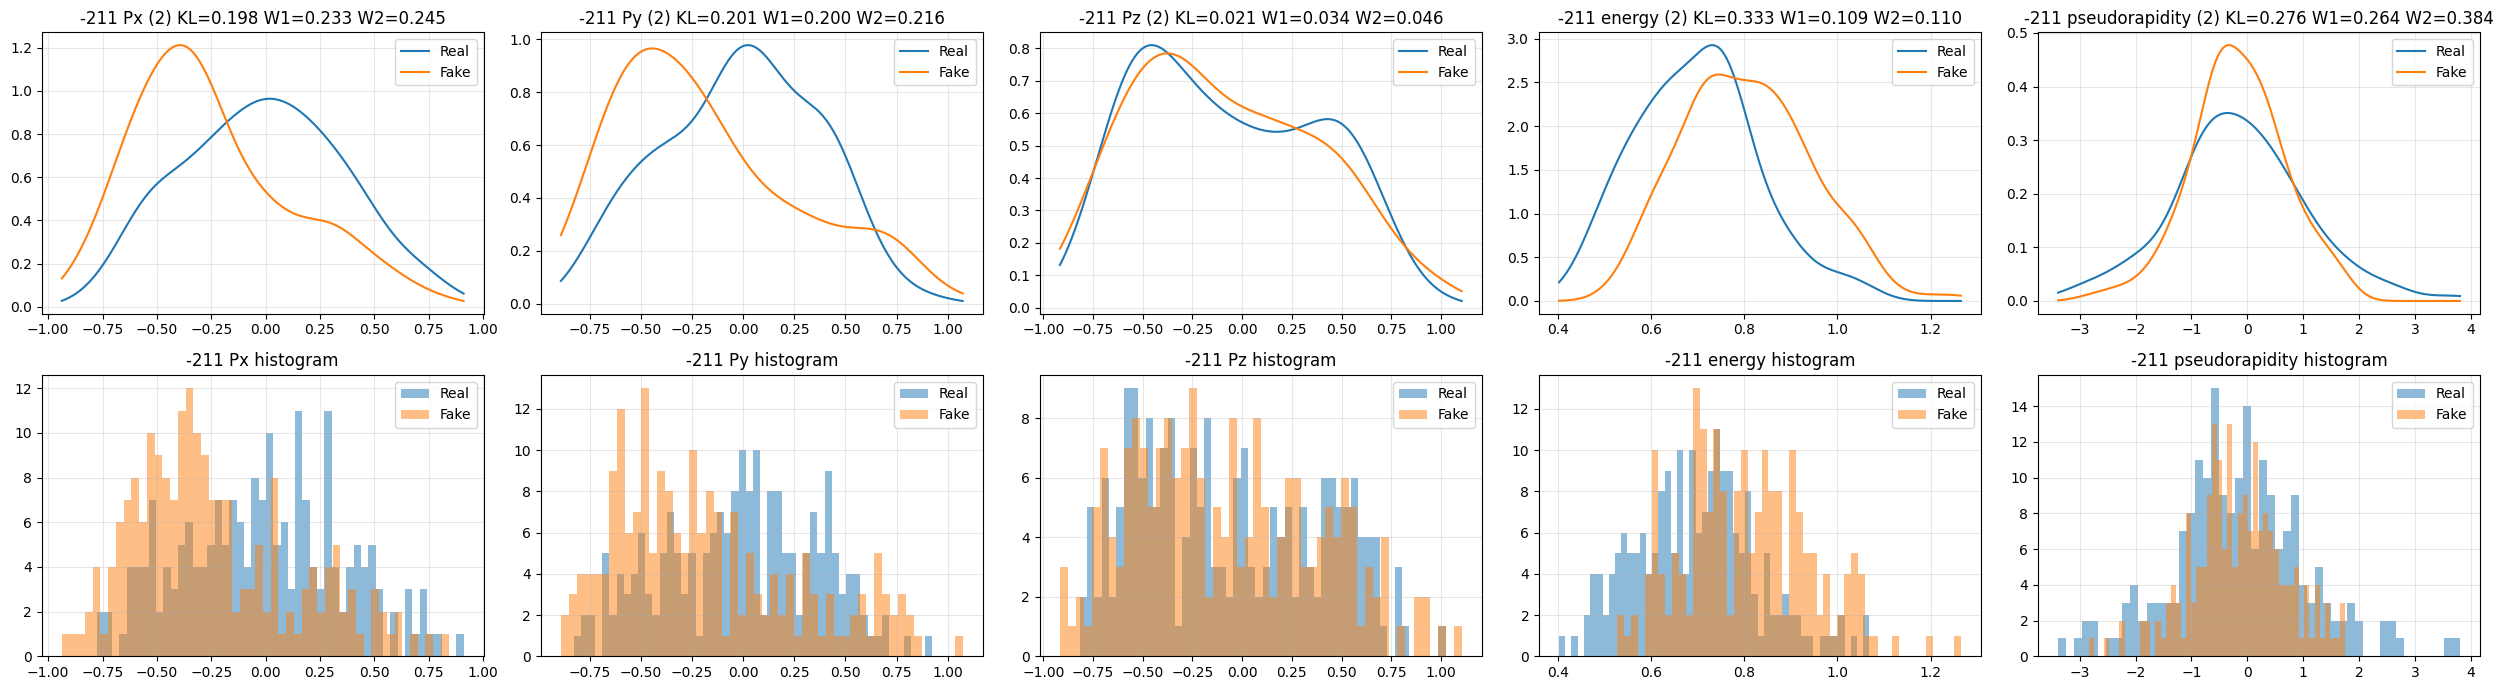

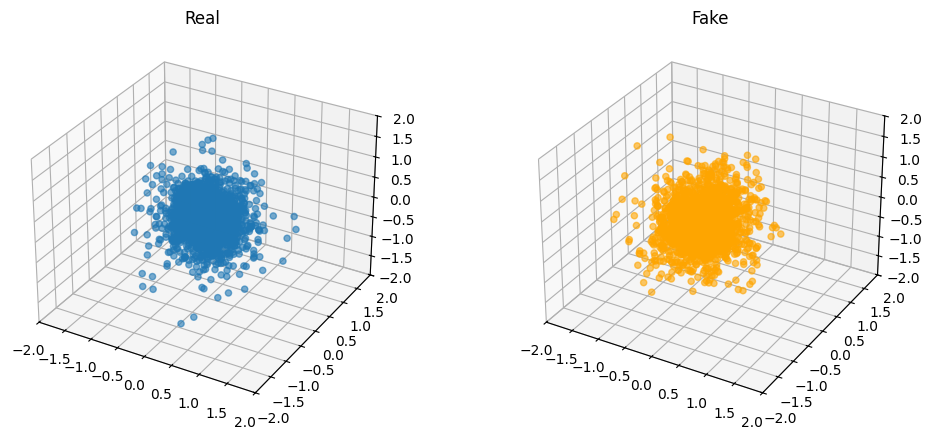

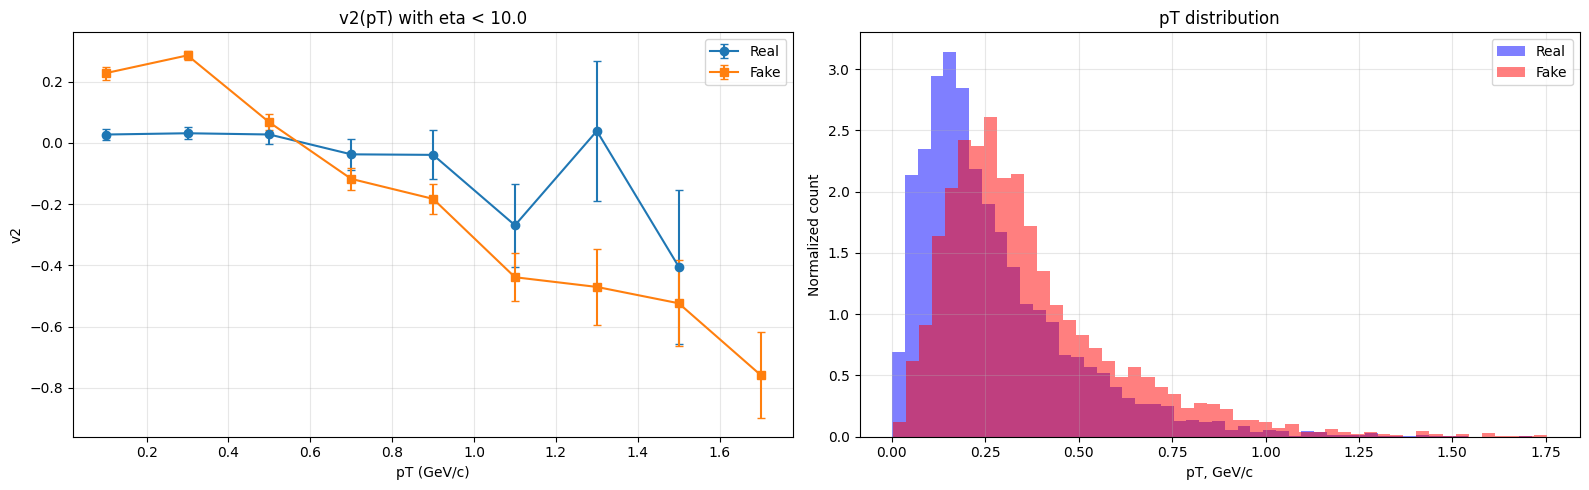

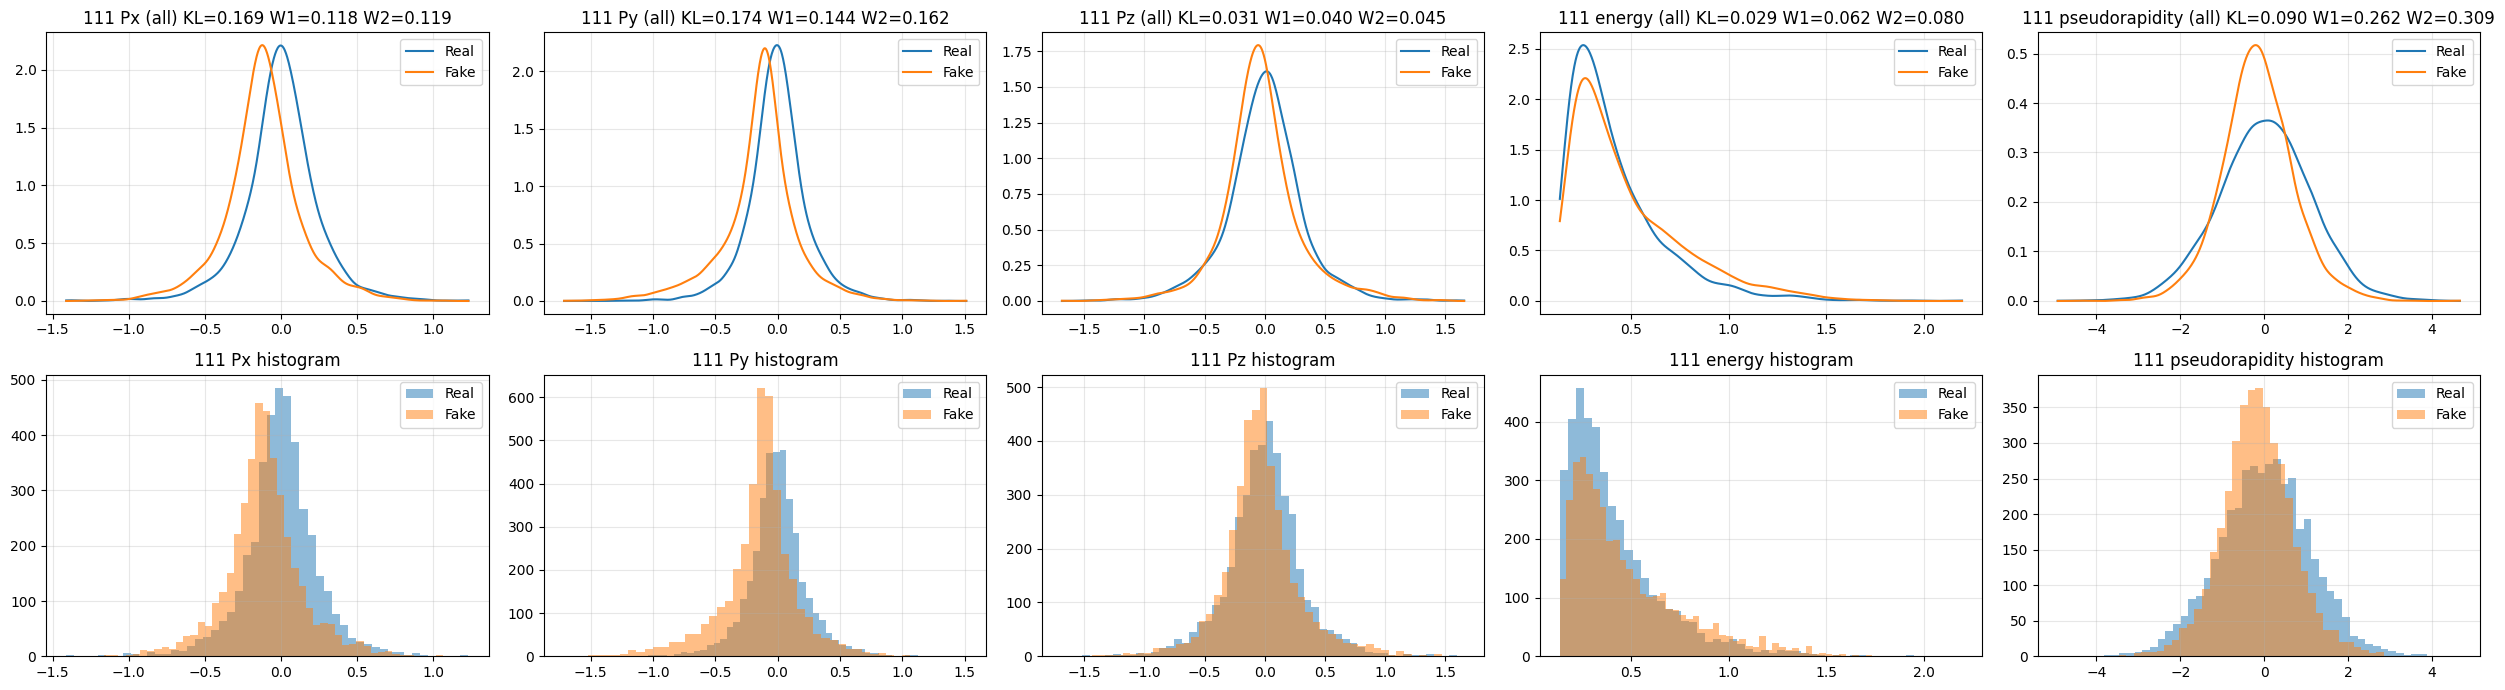

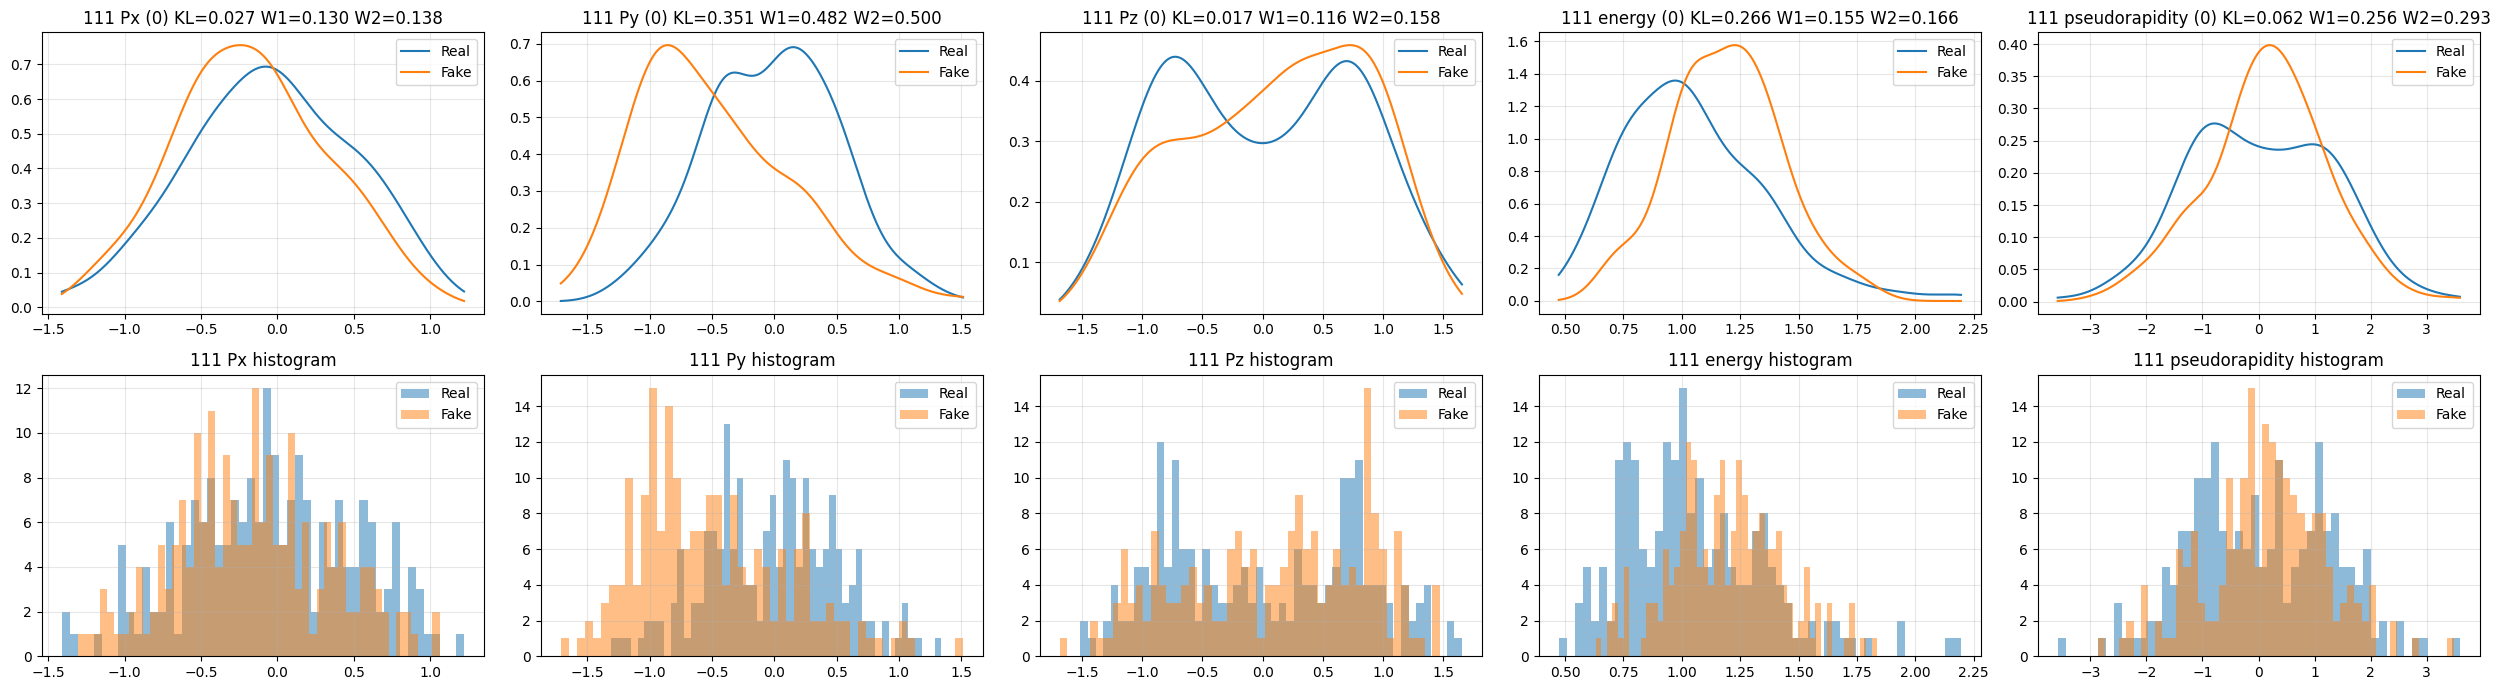

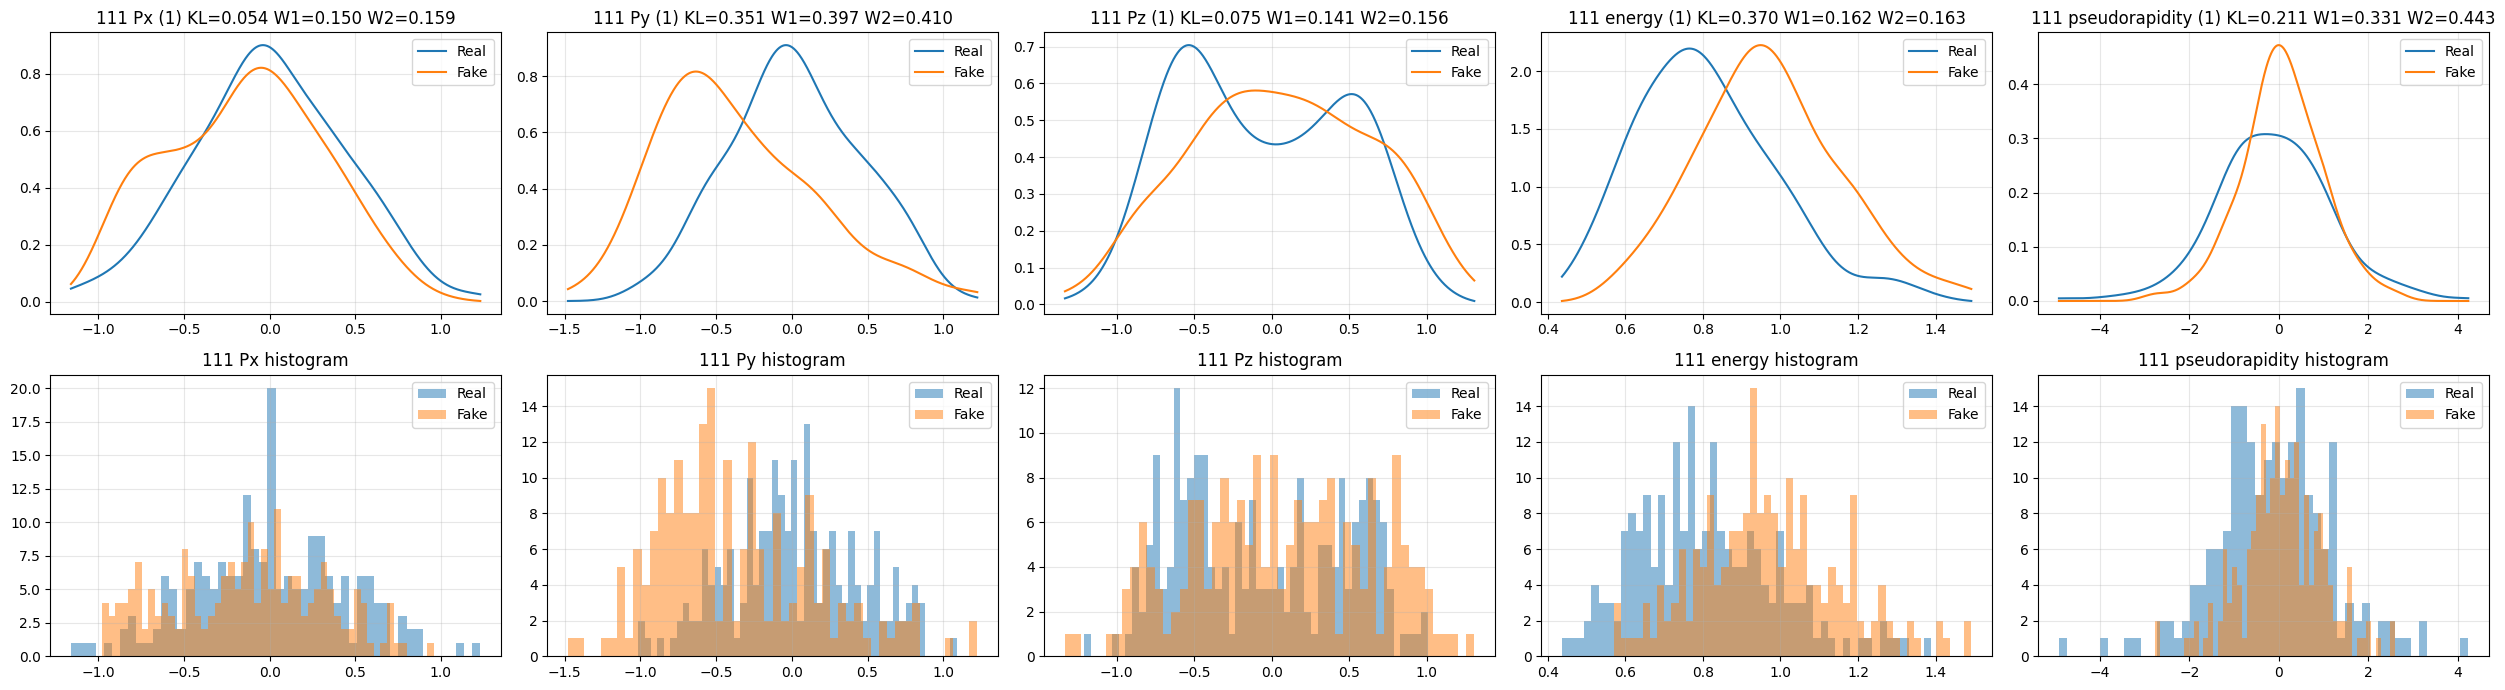

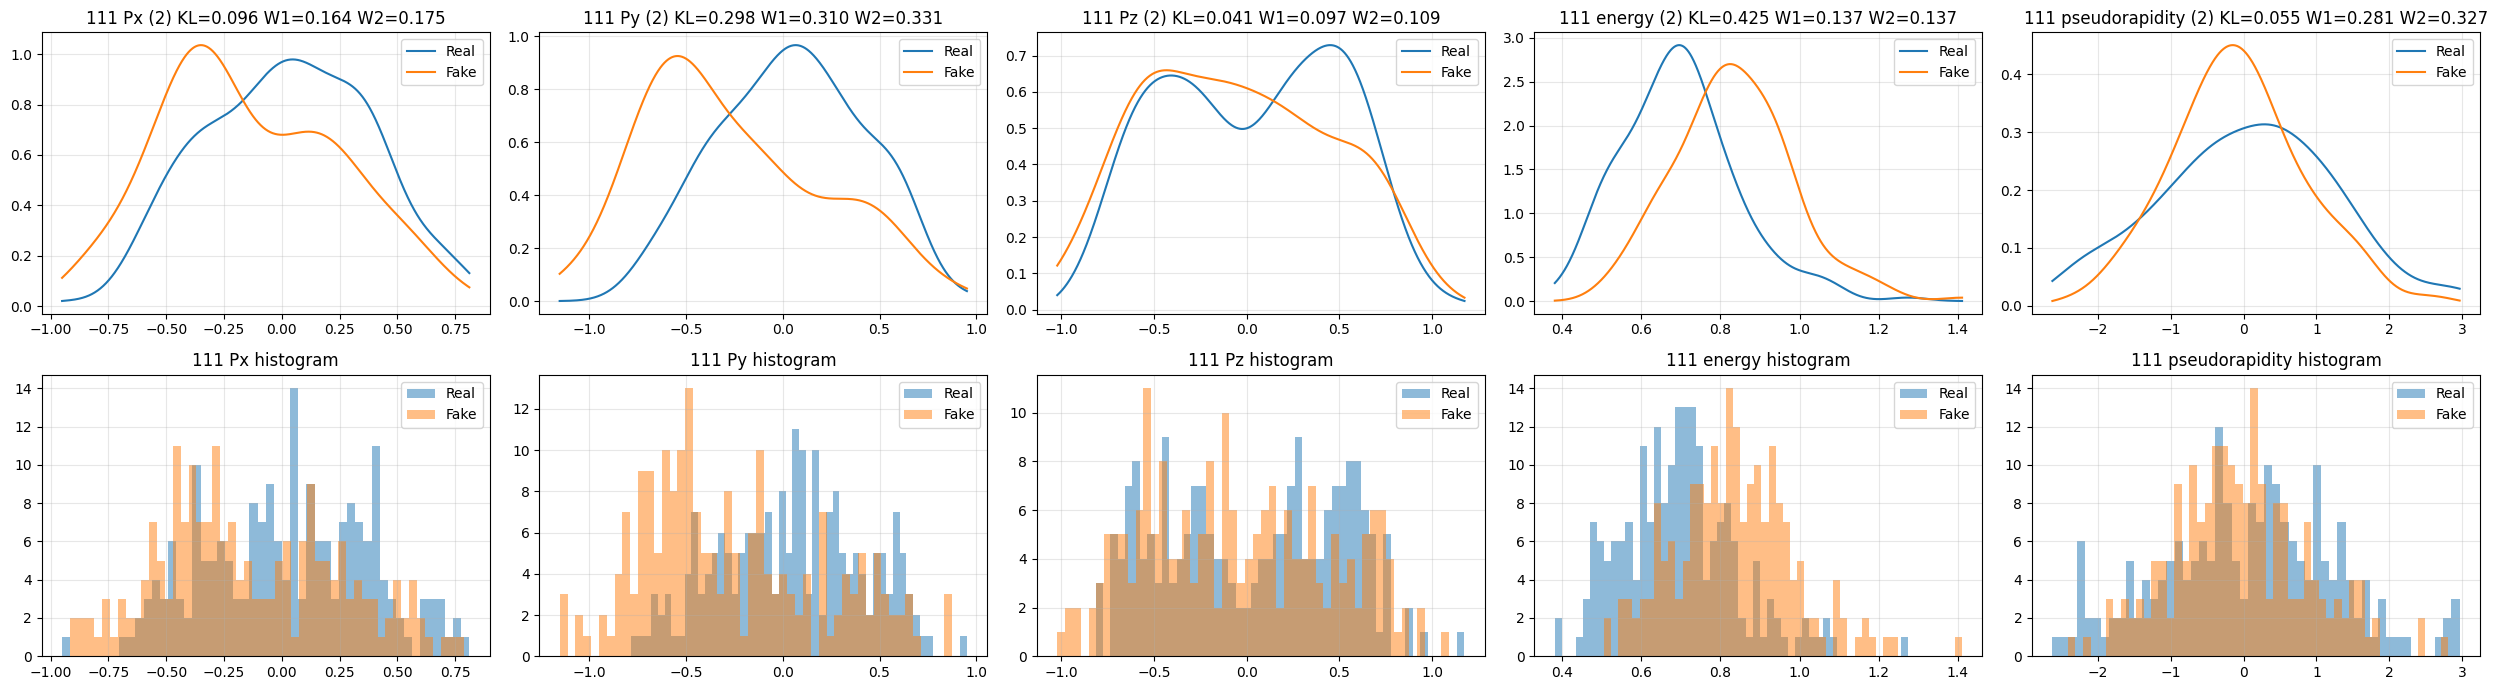

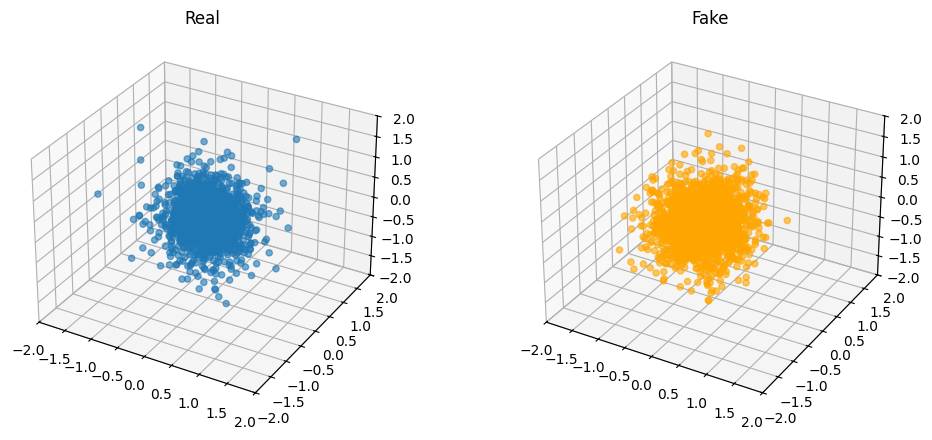

In [ ]:
latent_dim = 32
latent_local_dim = 32
hid_dim = 64
num_classes = len(pions)
feat_dim = 3
num_equiv_layers_gen = 5
num_equiv_layers_disc = 5
lr = 1e-4
extern_cond_d = len(cond_cols)
betas = (0.5, 0.999)

for n_modes in n_modes_lst:
    METRICS[n_modes] = {}

    for seed in seeds:
        METRICS[n_modes][seed] = {}
        set_seed(seed)

        G = EPiC_Transformer_Generator(
            latent_global=latent_dim,
            latent_local=latent_local_dim,
            num_labels=num_classes,
            feats=feat_dim,
            max_len=meson_count_max,
            d_model=2 * hid_dim,
            n_heads=8,
            extern_cond_d=extern_cond_d,
            d_ff=hid_dim,
            n_modes=n_modes,
            n_layers=num_equiv_layers_gen,
        ).to(device)

        D = EPiC_Transformer_Discriminator(
            num_labels=num_classes,
            feats=feat_dim,
            d_model=2 * hid_dim,
            n_heads=8,
            d_ff=hid_dim,
            extern_cond_d=extern_cond_d,
            n_layers=num_equiv_layers_gen,
        ).to(device)

        opt_g = optim.Adam(G.parameters(), lr=lr, betas=betas)
        opt_d = optim.Adam(D.parameters(), lr=lr, betas=betas)

        losses_my = train_model(
            G=G,
            D=D,
            dataloader=urqmd_train_dataloader,
            optim_G=opt_g,
            optim_D=opt_d,
            device=device,
            mode="lsgan",
            d_iters=1,
            epochs=epochs,
            train_epoch_func=train_epoch_my,
            generate_func=generate_my,
            test_mom=test_1_7_mom,
            test_cond=test_1_7_cond,
            test_label=test_1_7_label,
            test_mask=test_1_7_mask,
            num_classes=num_classes,
            meson_count_max=meson_count_max,
        )

        clear_output()

        METRICS[n_modes][seed][1.7] = get_dist_metrics(
            G,
            generate_my,
            test_1_7_mom,
            test_1_7_nucl,
            test_1_7_nucl_mask,
            test_1_7_event,
            test_1_7_cond,
            test_1_7_label,
            test_1_7_mask,
        )
        # get_energy_metrics(G, generate_my, test_1_7_mom,
        #                   test_1_7_nucl, test_1_7_nucl_mask, test_1_7_event,
        #                   test_1_7_cond, test_1_7_label, test_1_7_mask)
        METRICS[n_modes][seed][5] = get_dist_metrics(
            G,
            generate_my,
            test_5_mom,
            test_5_nucl,
            test_5_nucl_mask,
            test_5_event,
            test_5_cond,
            test_5_label,
            test_5_mask,
        )
        # get_energy_metrics(G, generate_my, test_5_mom,
        #                   test_5_nucl, test_5_nucl_mask, test_5_event,
        #                   test_5_cond, test_5_label, test_5_mask)

## Метрики

Ниже представлены усредненные по 3 seed'ам KL-дивергенция, W1- и W2-расстояния.

In [40]:
records = []
for n_modes, seeds in METRICS.items():
    for seed, bs in seeds.items():
        for b, pions in bs.items():
            for pion, model_metrics in pions.items():
                for metric, value in model_metrics.items():
                    records.append(
                        {
                            "n_modes": n_modes,
                            "seed": seed,
                            "b": b,
                            "pion": pion,
                            "metric": metric,
                            "value": value,
                        }
                    )
res = (
    pd.DataFrame(records)
    .groupby(["n_modes", "b", "pion", "metric"])["value"]
    .agg(["mean", "std"])
    .reset_index()
)
res[res.pion == 211]

,n_modes,b,pion,metric,mean,std
12,2,1.7,211,kl,0.015774,NaN
13,2,1.7,211,kl_0,0.067328,NaN
14,2,1.7,211,w1,0.102776,NaN
15,2,1.7,211,w1_0,0.253250,NaN
16,2,1.7,211,w2,0.123029,NaN
17,2,1.7,211,w2_0,0.315531,NaN
30,2,5.0,211,kl,0.037393,NaN
31,2,5.0,211,kl_0,0.082933,NaN
32,2,5.0,211,w1,0.148339,NaN
33,2,5.0,211,w1_0,0.305609,NaN


Посмотрим модели с максимальным и минимальным значением W1-расстояния для отрицательных и положительных пионов.

In [34]:
w1_minus_211 = res[(res.pion == -211) & (res.metric == "w1")]
w1_minus_211[
    (w1_minus_211["mean"] == w1_minus_211["mean"].min())
    | (w1_minus_211["mean"] == w1_minus_211["mean"].max())
]

,n_modes,b,pion,metric,mean,std
2,1,1.7,-211,w1,0.674765,NaN
38,2,1.7,-211,w1,0.123937,NaN


In [35]:
w1_211 = res[(res.pion == 211) & (res.metric == "w1")]
w1_211[
    (w1_211["mean"] == w1_211["mean"].min()) | (w1_211["mean"] == w1_211["mean"].max())
]

,n_modes,b,pion,metric,mean,std
32,1,5.0,211,w1,0.741872,NaN
50,2,1.7,211,w1,0.102776,NaN
